In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df1=pd.read_csv(filepath_or_buffer="/movies.csv",delimiter=",")
df1.head(10)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [12]:
df2=pd.read_csv(filepath_or_buffer="/links.csv",delimiter=",")
df2.head(10)

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0
5,6,113277,949.0
6,7,114319,11860.0
7,8,112302,45325.0
8,9,114576,9091.0
9,10,113189,710.0


In [16]:
df3=pd.read_csv(filepath_or_buffer="/ratings.csv",delimiter=",")
df3.head(10)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100


In [18]:
df4=pd.read_csv(filepath_or_buffer="/tags.csv",delimiter=",")
df4.head(10)

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
5,2,89774,Tom Hardy,1445715205
6,2,106782,drugs,1445715054
7,2,106782,Leonardo DiCaprio,1445715051
8,2,106782,Martin Scorsese,1445715056
9,7,48516,way too long,1169687325


In [21]:
from IPython.display import display, Markdown

def explorer_dataset(df, nom_table):
    """
    Explore et affiche les informations d'un DataFrame

    Args:
        df: DataFrame à explorer
        nom_table: Nom de la table à afficher
    """
    # 1. Dimensions et Types
    display(Markdown(f"### 📊 Aperçu Structurel - Table: {nom_table}"))
    print(f"Dimensions : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")

    # 2. Les 5 dernières lignes
    display(Markdown("---\n### 🔍 Dernières lignes"))
    display(df.tail())

    # 3. Échantillon aléatoire
    display(Markdown("---\n### 🎲 Échantillon aléatoire (5 lignes)"))
    display(df.sample(5))

    # 4. Santé des données
    display(Markdown("---\n### 🛠 Santé et Types des colonnes"))
    info_df = pd.DataFrame({
        'Type': df.dtypes,
        'Valeurs Manquantes': df.isna().sum(),
        '% Manquant': (df.isna().sum() / len(df) * 100).round(2).astype(str) + '%'
    })
    display(info_df)

    # 5. Statistiques descriptives
    display(Markdown("---\n### 📈 Statistiques des variables numériques"))
    display(df.describe())

    display(Markdown("---\n"))

# Version avec dictionnaire (plus scalable)
tables = {
    'movies': df1,
    'links': df2,
    'ratings': df3,
    'tags': df4
}

for nom_table, df in tables.items():
    explorer_dataset(df, nom_table)

# OU version simple (appels directs)
explorer_dataset(df1, 'movies')
explorer_dataset(df2, 'links')
explorer_dataset(df3, 'ratings')
explorer_dataset(df4, 'tags')

### 📊 Aperçu Structurel - Table: movies

Dimensions : 9742 lignes et 3 colonnes



---
### 🔍 Dernières lignes

,movieId,title,genres
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation
9741,193609,Andrew Dice Clay: Dice Rules (1991),Comedy


---
### 🎲 Échantillon aléatoire (5 lignes)

,movieId,title,genres
8715,125970,Halloweentown (1998),Adventure|Children|Comedy|Fantasy
4322,6315,Wildcats (1986),Comedy
5165,8366,Saved! (2004),Comedy|Drama
8890,134393,Trainwreck (2015),Comedy|Romance
7573,86000,Boy (2010),Comedy|Drama


---
### 🛠 Santé et Types des colonnes

,Type,Valeurs Manquantes,% Manquant
movieId,int64,0,0.0%
title,object,0,0.0%
genres,object,0,0.0%


---
### 📈 Statistiques des variables numériques

,movieId
count,9742.000000
mean,42200.353623
std,52160.494854
min,1.000000
25%,3248.250000
50%,7300.000000
75%,76232.000000
max,193609.000000


---


### 📊 Aperçu Structurel - Table: links

Dimensions : 9742 lignes et 3 colonnes



---
### 🔍 Dernières lignes

,movieId,imdbId,tmdbId
9737,193581,5476944,432131.0
9738,193583,5914996,445030.0
9739,193585,6397426,479308.0
9740,193587,8391976,483455.0
9741,193609,101726,37891.0


---
### 🎲 Échantillon aléatoire (5 lignes)

,movieId,imdbId,tmdbId
2554,3420,78718,17443.0
2094,2788,66765,9267.0
1746,2342,116488,21589.0
5440,25996,47522,3111.0
9598,175707,5135434,411516.0


---
### 🛠 Santé et Types des colonnes

,Type,Valeurs Manquantes,% Manquant
movieId,int64,0,0.0%
imdbId,int64,0,0.0%
tmdbId,float64,8,0.08%


---
### 📈 Statistiques des variables numériques

,movieId,imdbId,tmdbId
count,9742.000000,9.742000e+03,9734.000000
mean,42200.353623,6.771839e+05,55162.123793
std,52160.494854,1.107228e+06,93653.481487
min,1.000000,4.170000e+02,2.000000
25%,3248.250000,9.518075e+04,9665.500000
50%,7300.000000,1.672605e+05,16529.000000
75%,76232.000000,8.055685e+05,44205.750000
max,193609.000000,8.391976e+06,525662.000000


---


### 📊 Aperçu Structurel - Table: ratings

Dimensions : 100836 lignes et 4 colonnes



---
### 🔍 Dernières lignes

,userId,movieId,rating,timestamp
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352
100835,610,170875,3.0,1493846415


---
### 🎲 Échantillon aléatoire (5 lignes)

,userId,movieId,rating,timestamp
89222,578,6751,2.5,1300990921
28118,195,866,4.0,974705903
54317,357,2352,3.0,1348609806
14187,91,367,3.5,1112713273
46452,305,87485,5.0,1460222264


---
### 🛠 Santé et Types des colonnes

,Type,Valeurs Manquantes,% Manquant
userId,int64,0,0.0%
movieId,int64,0,0.0%
rating,float64,0,0.0%
timestamp,int64,0,0.0%


---
### 📈 Statistiques des variables numériques

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


---


### 📊 Aperçu Structurel - Table: tags

Dimensions : 3683 lignes et 4 colonnes



---
### 🔍 Dernières lignes

,userId,movieId,tag,timestamp
3678,606,7382,for katie,1171234019
3679,606,7936,austere,1173392334
3680,610,3265,gun fu,1493843984
3681,610,3265,heroic bloodshed,1493843978
3682,610,168248,Heroic Bloodshed,1493844270


---
### 🎲 Échantillon aléatoire (5 lignes)

,userId,movieId,tag,timestamp
1448,474,1423,Vietnam,1137202085
425,119,115617,animation,1435944890
3,2,89774,Boxing story,1445715207
1452,474,1466,Mafia,1137191577
3288,567,164179,thought-provoking,1525285688


---
### 🛠 Santé et Types des colonnes

,Type,Valeurs Manquantes,% Manquant
userId,int64,0,0.0%
movieId,int64,0,0.0%
tag,object,0,0.0%
timestamp,int64,0,0.0%


---
### 📈 Statistiques des variables numériques

,userId,movieId,timestamp
count,3683.000000,3683.000000,3.683000e+03
mean,431.149335,27252.013576,1.320032e+09
std,158.472553,43490.558803,1.721025e+08
min,2.000000,1.000000,1.137179e+09
25%,424.000000,1262.500000,1.137521e+09
50%,474.000000,4454.000000,1.269833e+09
75%,477.000000,39263.000000,1.498457e+09
max,610.000000,193565.000000,1.537099e+09


---


### 📊 Aperçu Structurel - Table: movies

Dimensions : 9742 lignes et 3 colonnes



---
### 🔍 Dernières lignes

,movieId,title,genres
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation
9741,193609,Andrew Dice Clay: Dice Rules (1991),Comedy


---
### 🎲 Échantillon aléatoire (5 lignes)

,movieId,title,genres
7095,70336,G.I. Joe: The Rise of Cobra (2009),Action|Adventure|Sci-Fi|Thriller
3801,5319,Nine Queens (Nueve reinas) (2000),Crime|Thriller
4259,6215,Laurel Canyon (2002),Drama
4865,7285,Thirteen (2003),Drama
2524,3384,"Taking of Pelham One Two Three, The (1974)",Action|Crime


---
### 🛠 Santé et Types des colonnes

,Type,Valeurs Manquantes,% Manquant
movieId,int64,0,0.0%
title,object,0,0.0%
genres,object,0,0.0%


---
### 📈 Statistiques des variables numériques

,movieId
count,9742.000000
mean,42200.353623
std,52160.494854
min,1.000000
25%,3248.250000
50%,7300.000000
75%,76232.000000
max,193609.000000


---


### 📊 Aperçu Structurel - Table: links

Dimensions : 9742 lignes et 3 colonnes



---
### 🔍 Dernières lignes

,movieId,imdbId,tmdbId
9737,193581,5476944,432131.0
9738,193583,5914996,445030.0
9739,193585,6397426,479308.0
9740,193587,8391976,483455.0
9741,193609,101726,37891.0


---
### 🎲 Échantillon aléatoire (5 lignes)

,movieId,imdbId,tmdbId
6385,50440,772193,4283.0
3206,4326,95647,1632.0
2173,2889,134618,15198.0
6039,39446,432348,215.0
6095,42018,413015,10773.0


---
### 🛠 Santé et Types des colonnes

,Type,Valeurs Manquantes,% Manquant
movieId,int64,0,0.0%
imdbId,int64,0,0.0%
tmdbId,float64,8,0.08%


---
### 📈 Statistiques des variables numériques

,movieId,imdbId,tmdbId
count,9742.000000,9.742000e+03,9734.000000
mean,42200.353623,6.771839e+05,55162.123793
std,52160.494854,1.107228e+06,93653.481487
min,1.000000,4.170000e+02,2.000000
25%,3248.250000,9.518075e+04,9665.500000
50%,7300.000000,1.672605e+05,16529.000000
75%,76232.000000,8.055685e+05,44205.750000
max,193609.000000,8.391976e+06,525662.000000


---


### 📊 Aperçu Structurel - Table: ratings

Dimensions : 100836 lignes et 4 colonnes



---
### 🔍 Dernières lignes

,userId,movieId,rating,timestamp
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352
100835,610,170875,3.0,1493846415


---
### 🎲 Échantillon aléatoire (5 lignes)

,userId,movieId,rating,timestamp
26545,182,2872,3.5,1054783747
84868,551,34162,4.0,1504925858
26282,182,1237,5.0,1054780648
84924,551,159093,4.0,1504926025
88871,573,8798,4.0,1186722613


---
### 🛠 Santé et Types des colonnes

,Type,Valeurs Manquantes,% Manquant
userId,int64,0,0.0%
movieId,int64,0,0.0%
rating,float64,0,0.0%
timestamp,int64,0,0.0%


---
### 📈 Statistiques des variables numériques

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


---


### 📊 Aperçu Structurel - Table: tags

Dimensions : 3683 lignes et 4 colonnes



---
### 🔍 Dernières lignes

,userId,movieId,tag,timestamp
3678,606,7382,for katie,1171234019
3679,606,7936,austere,1173392334
3680,610,3265,gun fu,1493843984
3681,610,3265,heroic bloodshed,1493843978
3682,610,168248,Heroic Bloodshed,1493844270


---
### 🎲 Échantillon aléatoire (5 lignes)

,userId,movieId,tag,timestamp
2419,474,27838,revenge,1137205953
2757,477,79132,visually appealing,1280608181
674,357,48516,Leonardo DiCaprio,1348627149
862,424,4816,ben stiller,1457846960
2845,537,80489,too much love interest,1424139454


---
### 🛠 Santé et Types des colonnes

,Type,Valeurs Manquantes,% Manquant
userId,int64,0,0.0%
movieId,int64,0,0.0%
tag,object,0,0.0%
timestamp,int64,0,0.0%


---
### 📈 Statistiques des variables numériques

,userId,movieId,timestamp
count,3683.000000,3683.000000,3.683000e+03
mean,431.149335,27252.013576,1.320032e+09
std,158.472553,43490.558803,1.721025e+08
min,2.000000,1.000000,1.137179e+09
25%,424.000000,1262.500000,1.137521e+09
50%,474.000000,4454.000000,1.269833e+09
75%,477.000000,39263.000000,1.498457e+09
max,610.000000,193565.000000,1.537099e+09


---


- La colonne movieId dans la table movies est un entier. Comme des calculs vont s'effectuer dessus, je dois la transformer en objet. On observe aucune valeur manquante pour cette table.

- Dans la table links, movieId, imdbId et tmdbId sont des entiers et réels. Des valeurs manquantes sont présentes pour la colonne tmdbId.

- Dans la table ratings, userId et movieId sont des entiers et doivent être transformés en objets. La colonne timestamp est un entier et doit être convertie en datetime. Aucune valeur manquante n'est observée.
- Dans la table tags, userId et movieId sont des entiers et doivent être transformés en objets. La colonne timestamp est un entier et doit être convertie en datetime. Aucune valeur manquante n'est observée.


In [10]:
# Rapport complet de la qualite des donnees

! pip3 install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 92.5 MB/s eta 0:00:00


⏳ Génération du rapport pour: movies...


                                             |          | [  0%]   00:00 -> (? left)


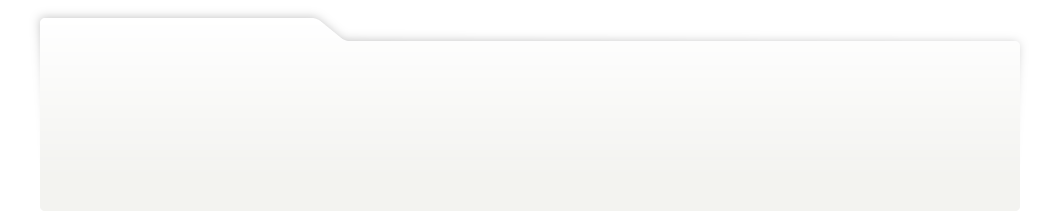
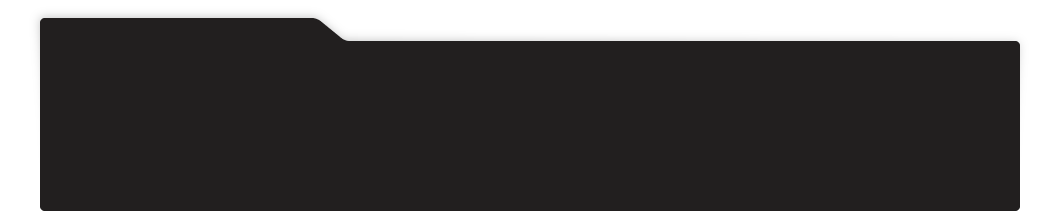
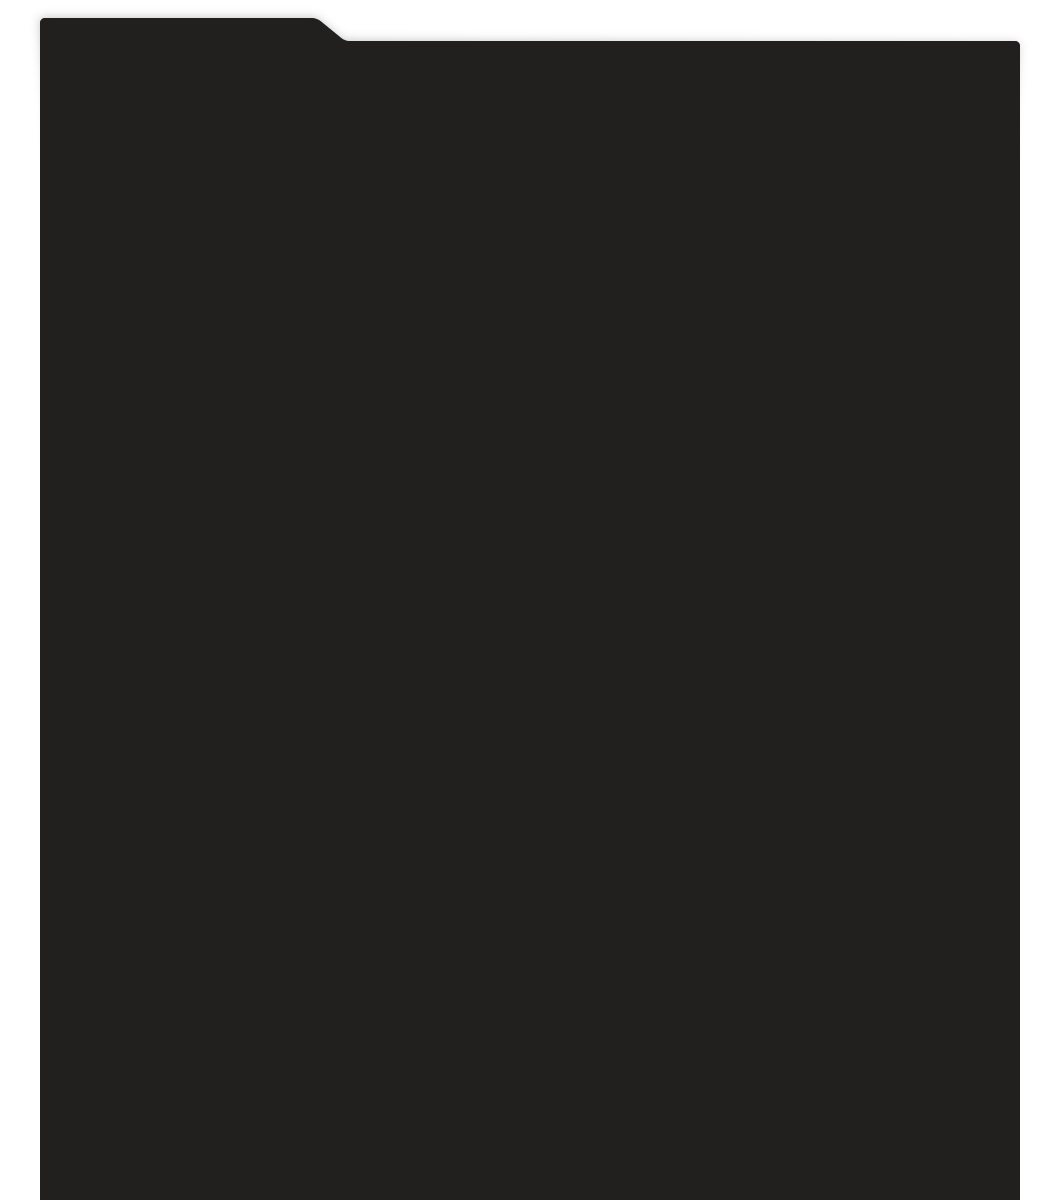
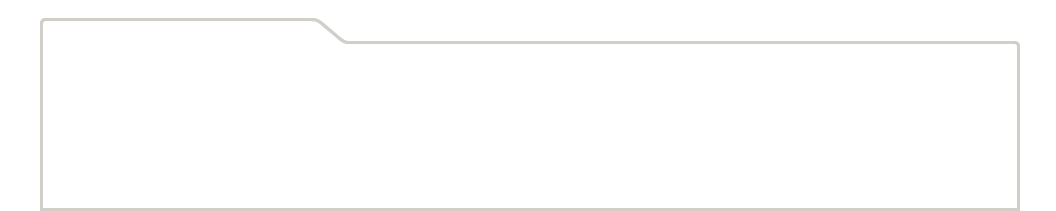
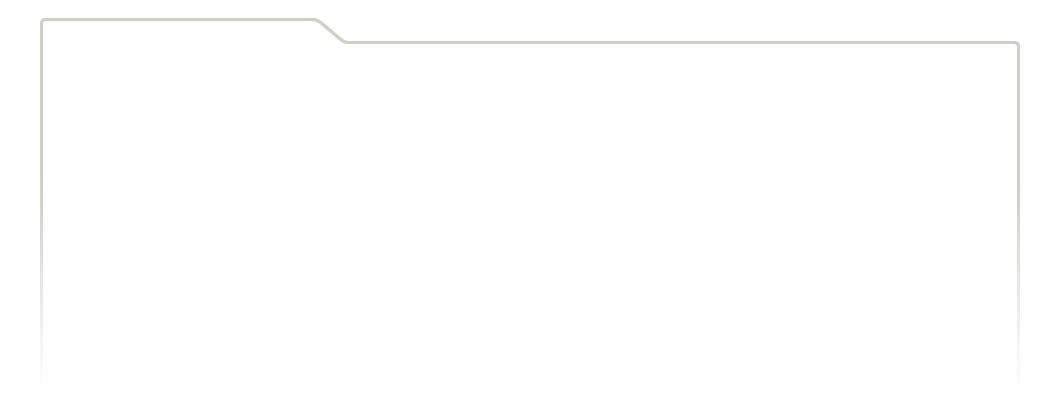
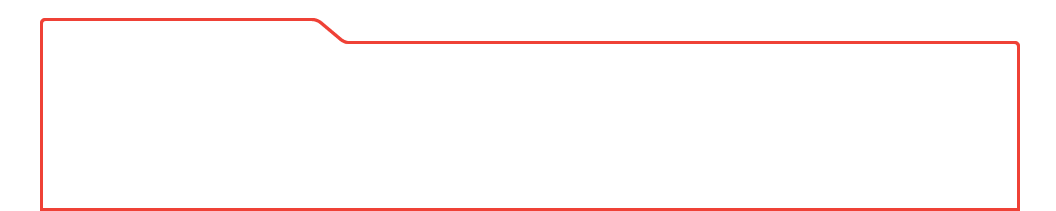
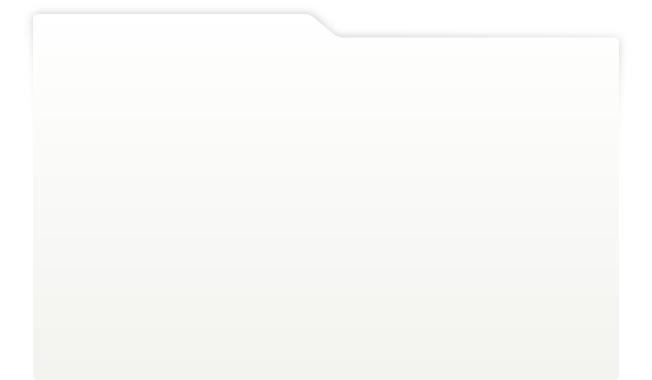
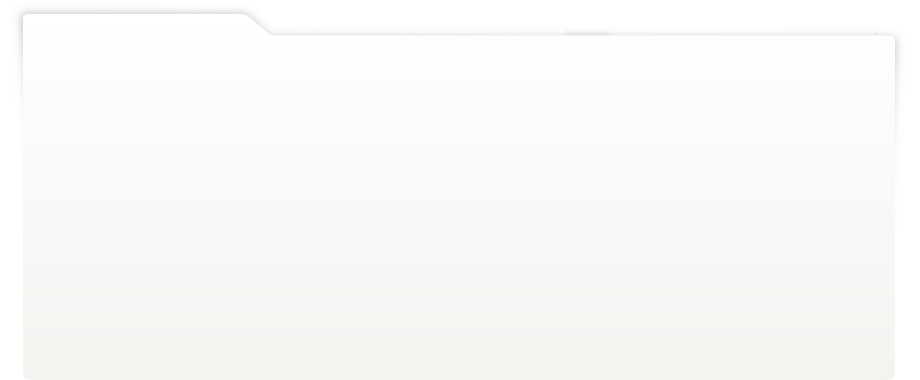
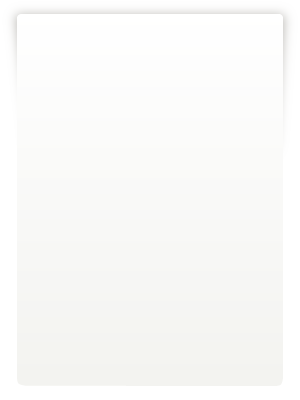
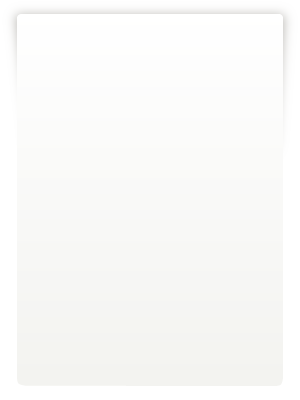
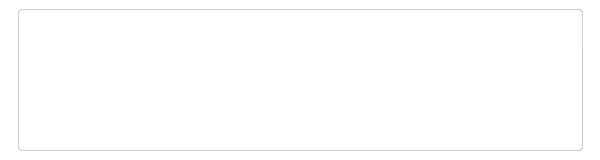
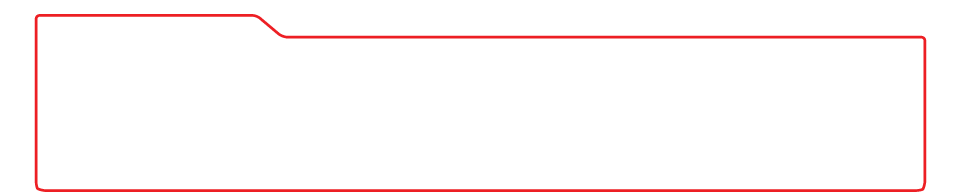
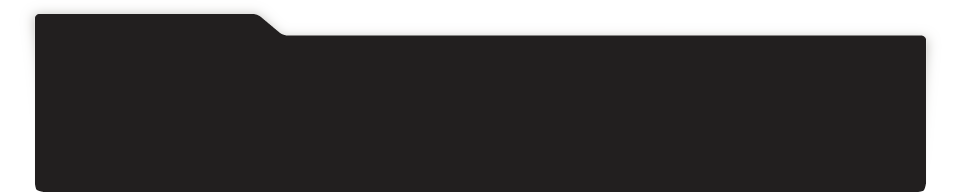
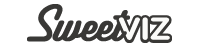
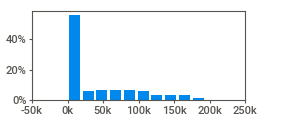
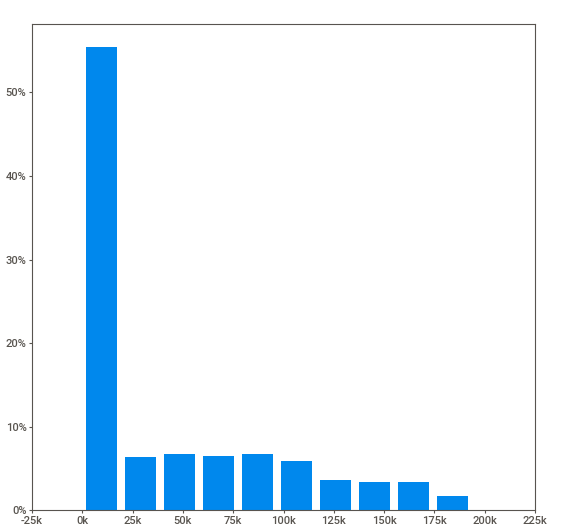
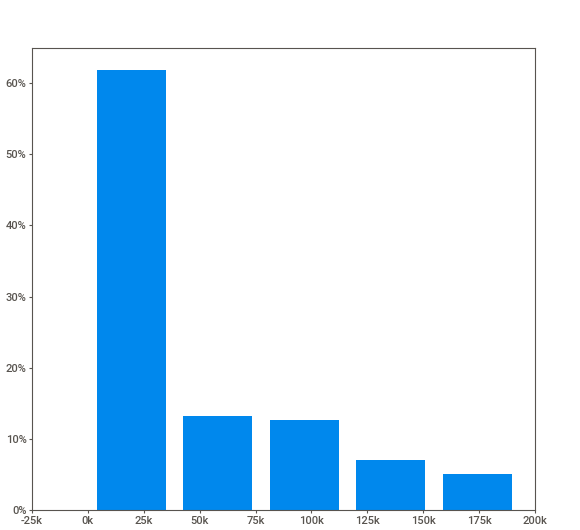
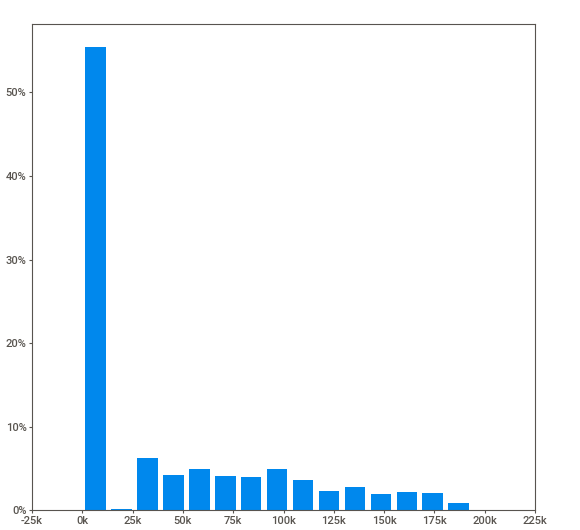
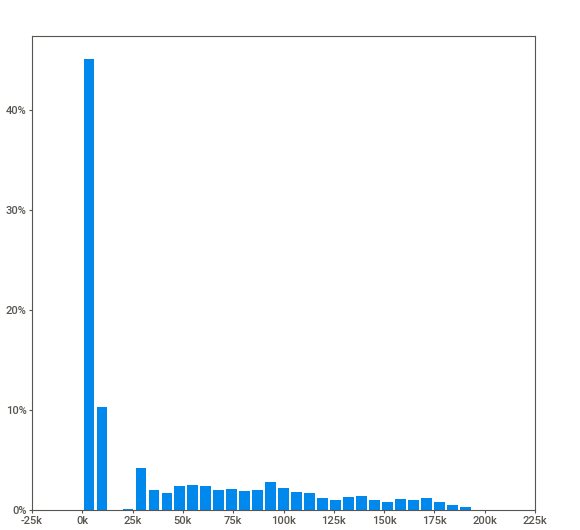
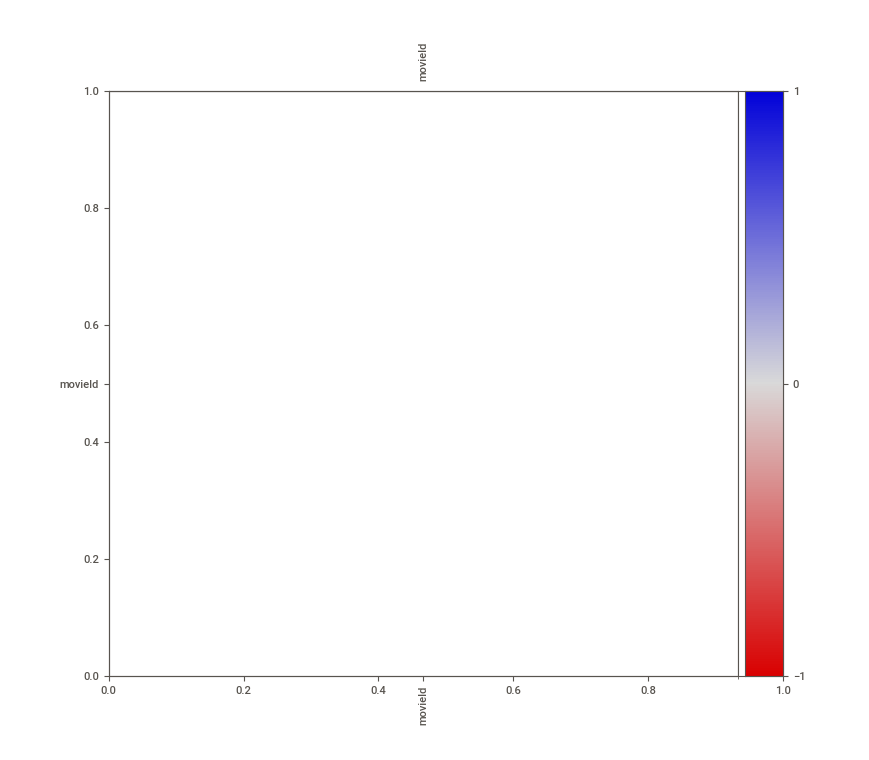
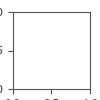

✅ movies analysé - 9742 lignes, 3 colonnes

⏳ Génération du rapport pour: links...


                                             |          | [  0%]   00:00 -> (? left)


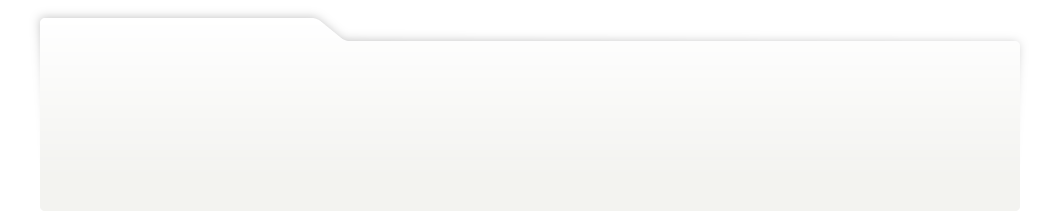
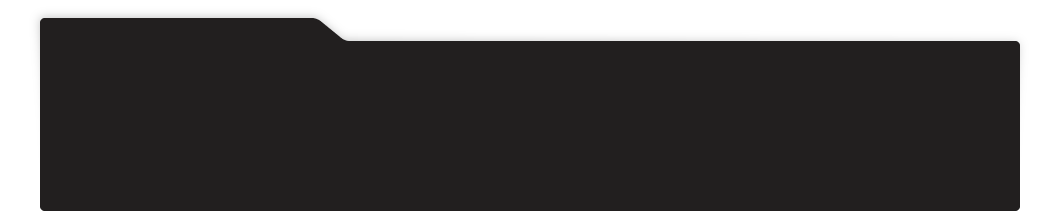
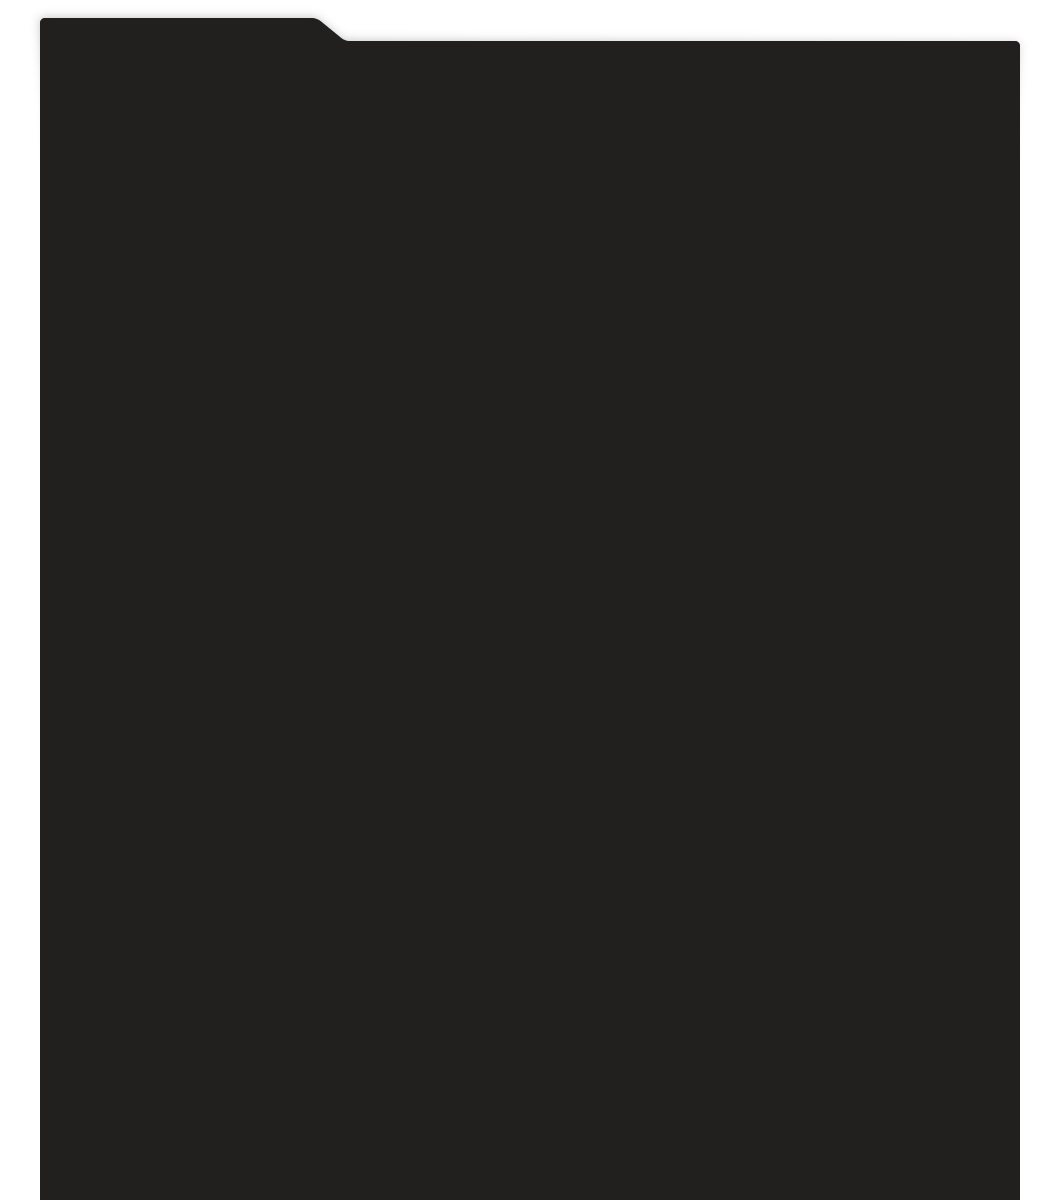
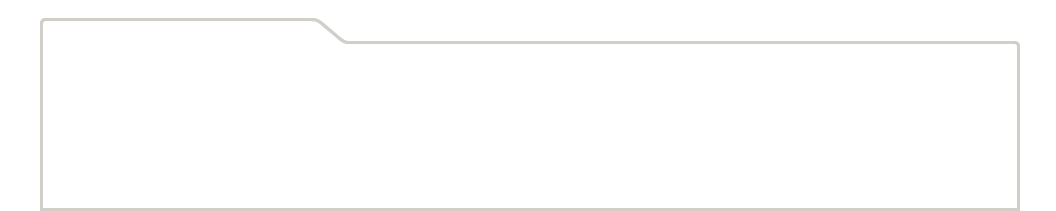
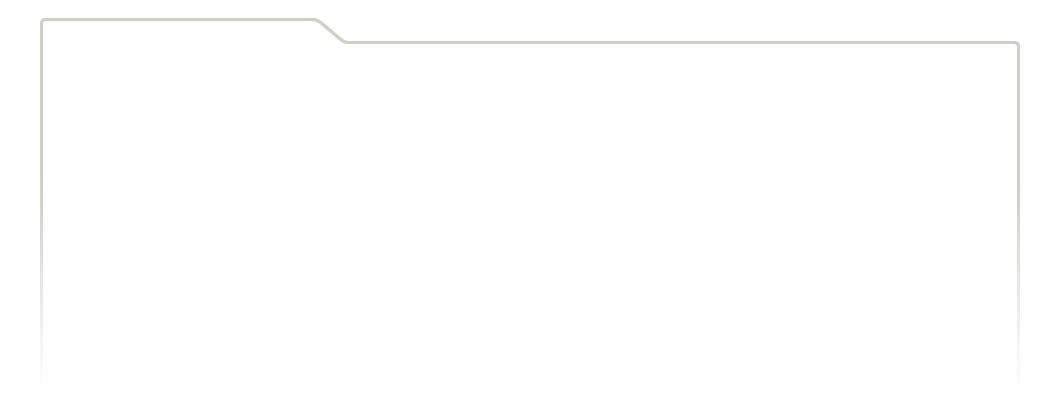
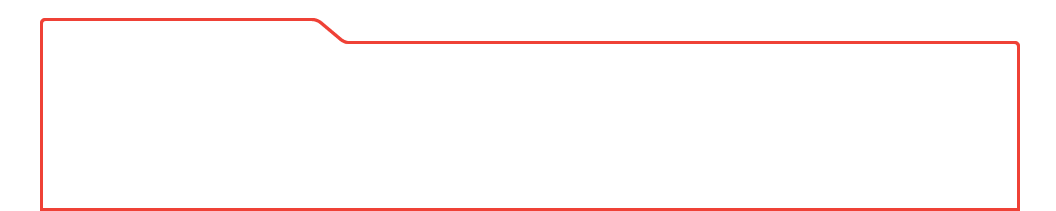
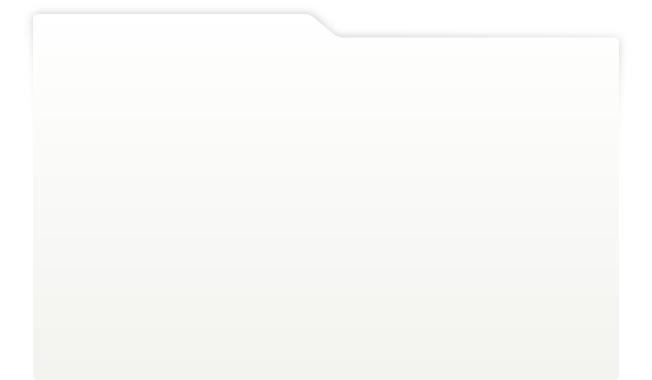
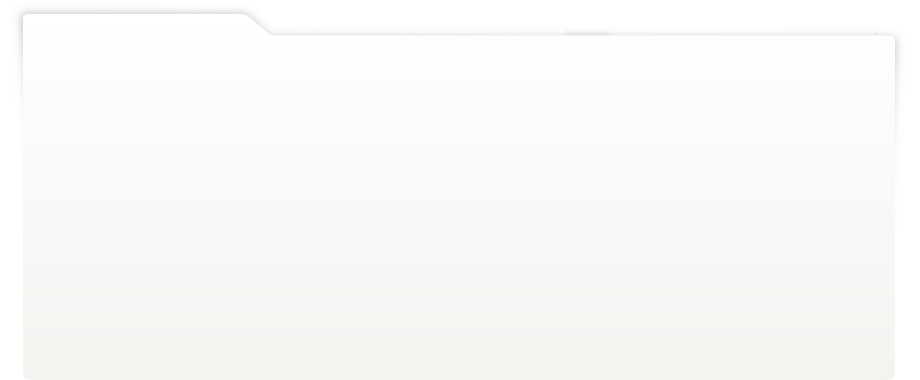
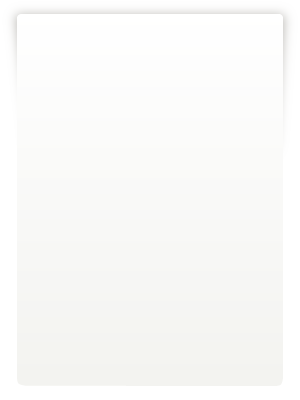
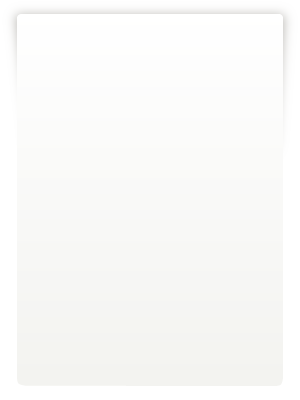
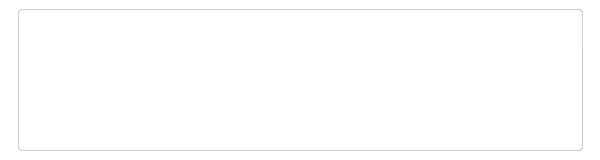
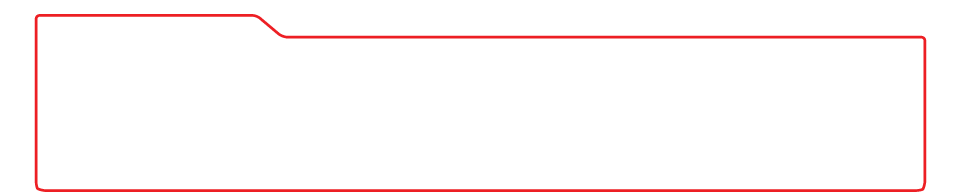
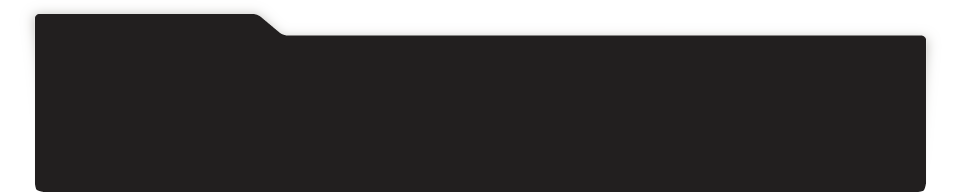
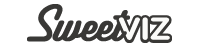
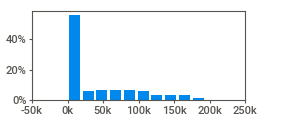
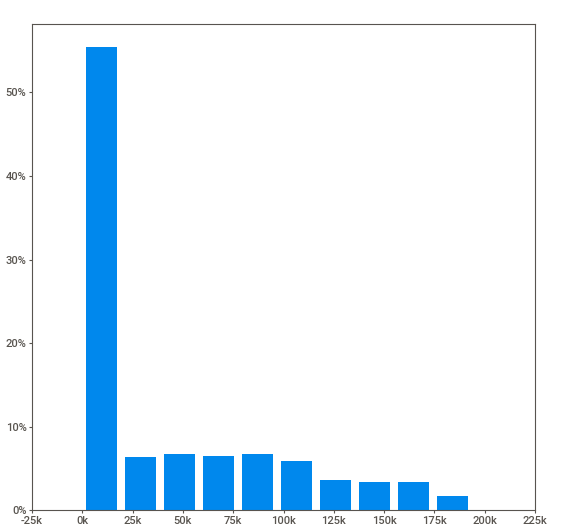
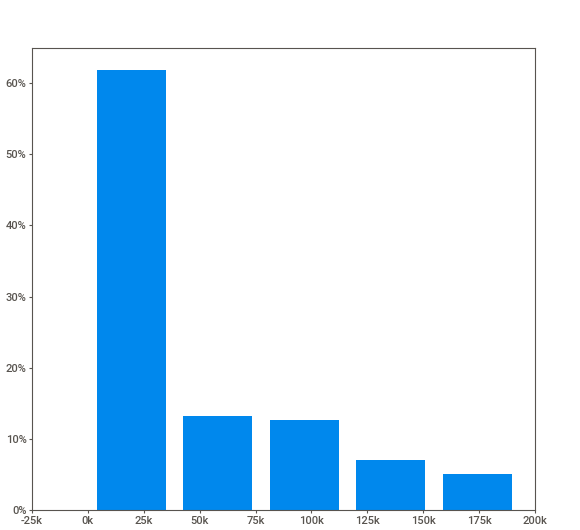
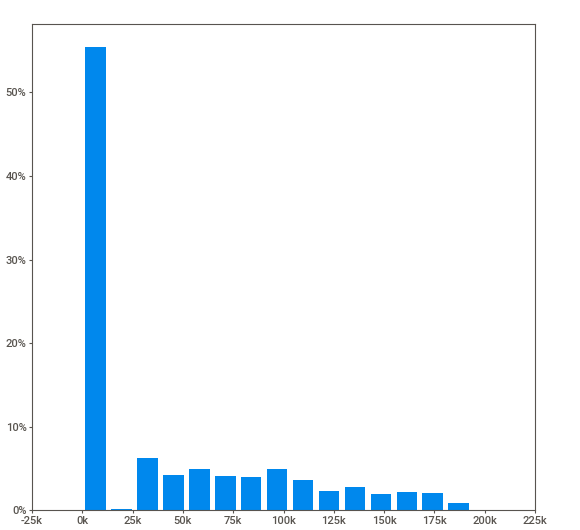
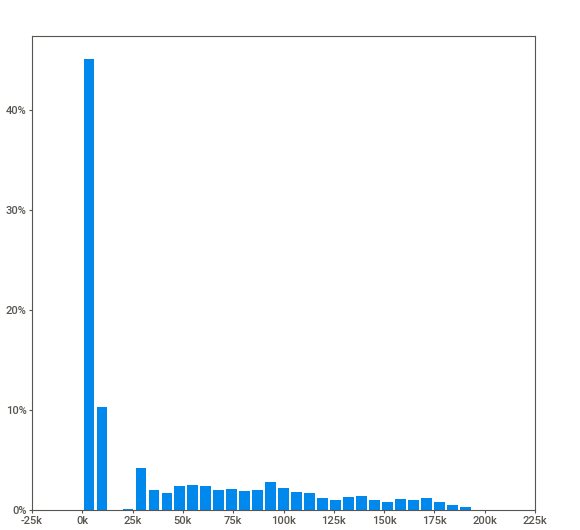
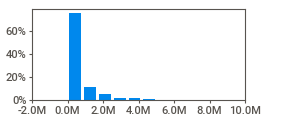
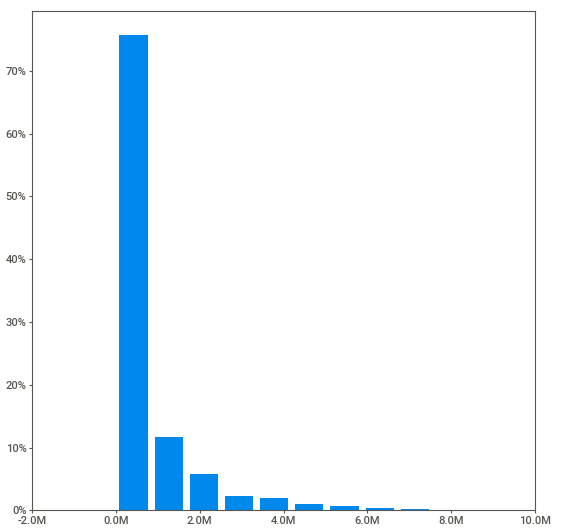
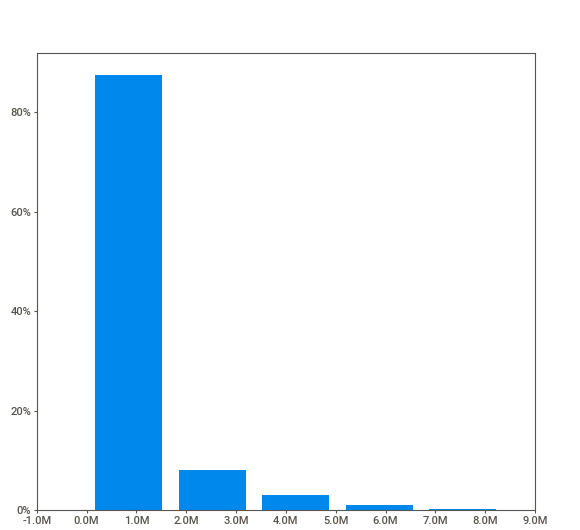
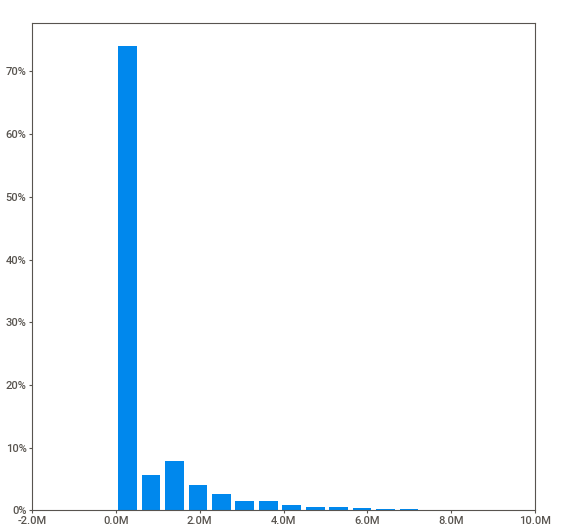
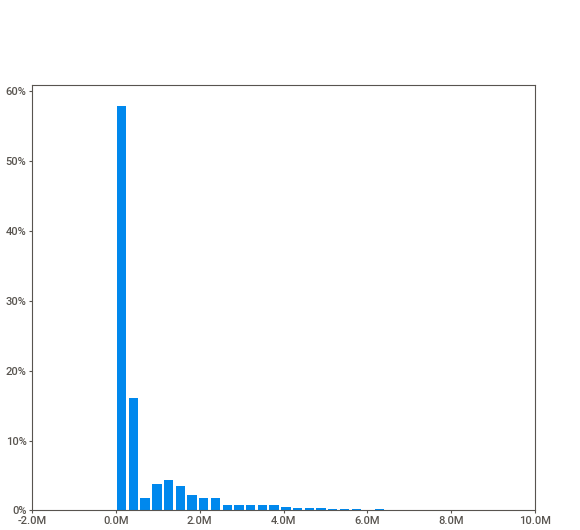
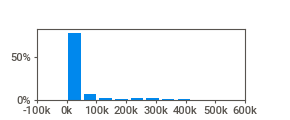
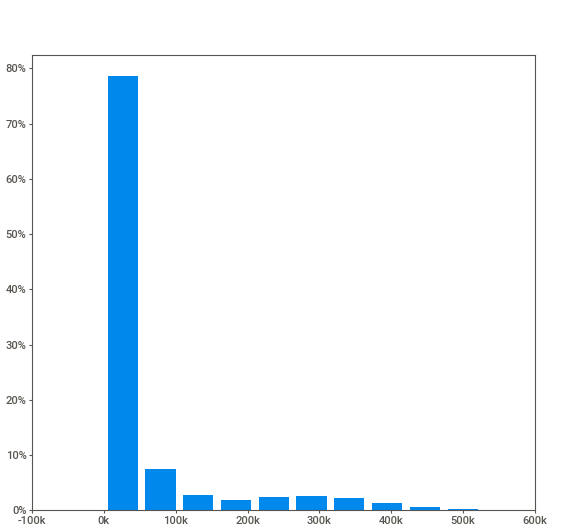
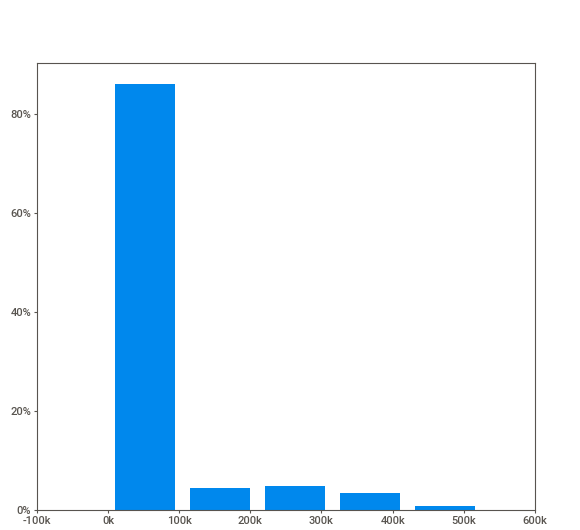
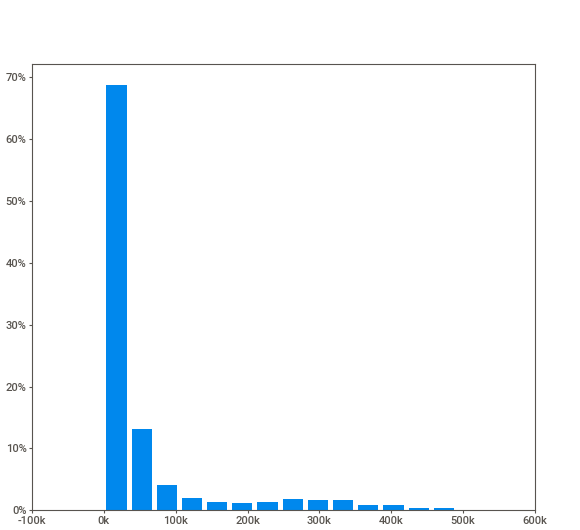
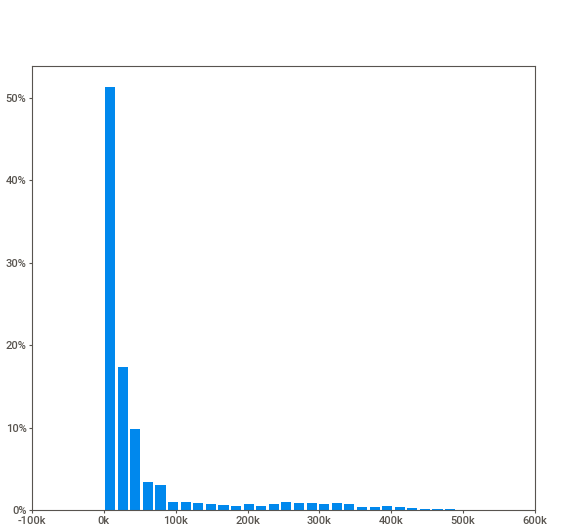
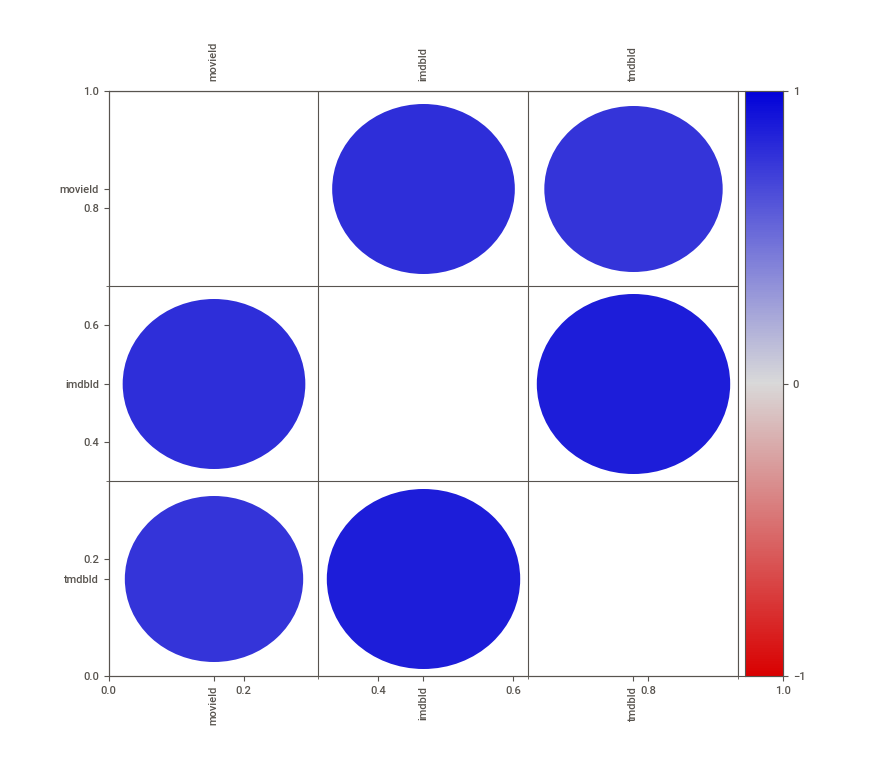
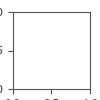

✅ links analysé - 9742 lignes, 3 colonnes

⏳ Génération du rapport pour: ratings...


                                             |          | [  0%]   00:00 -> (? left)


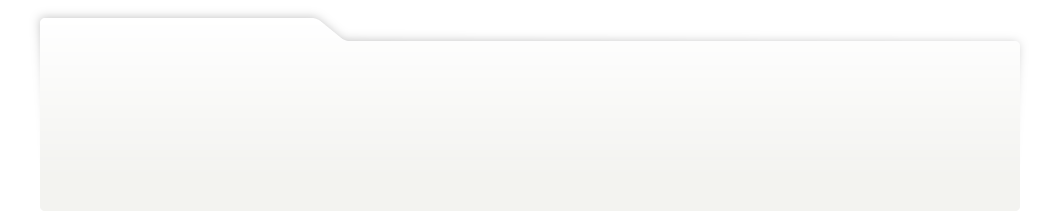
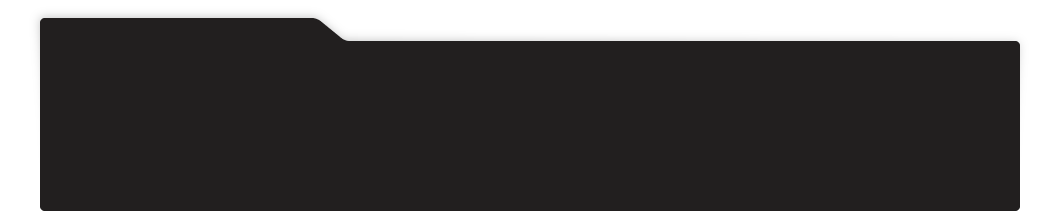
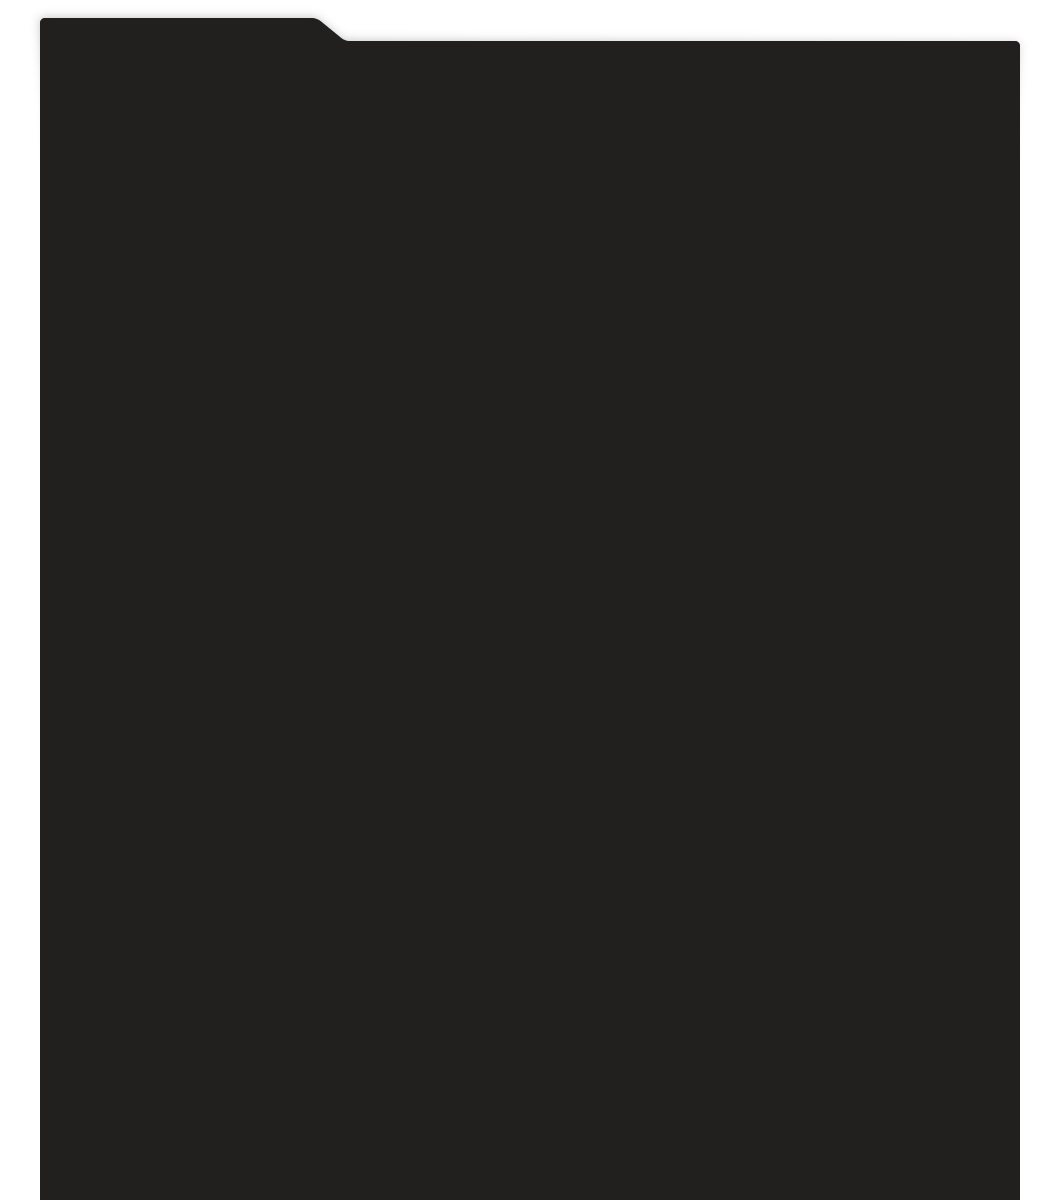
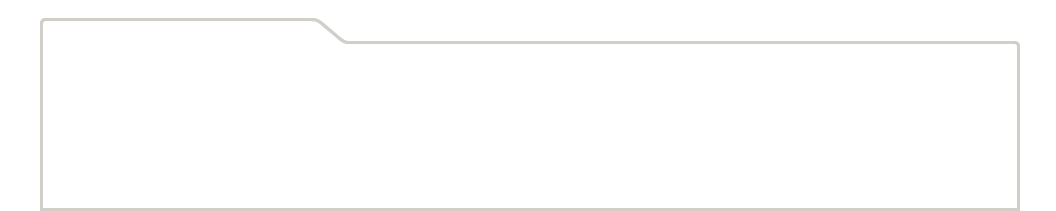
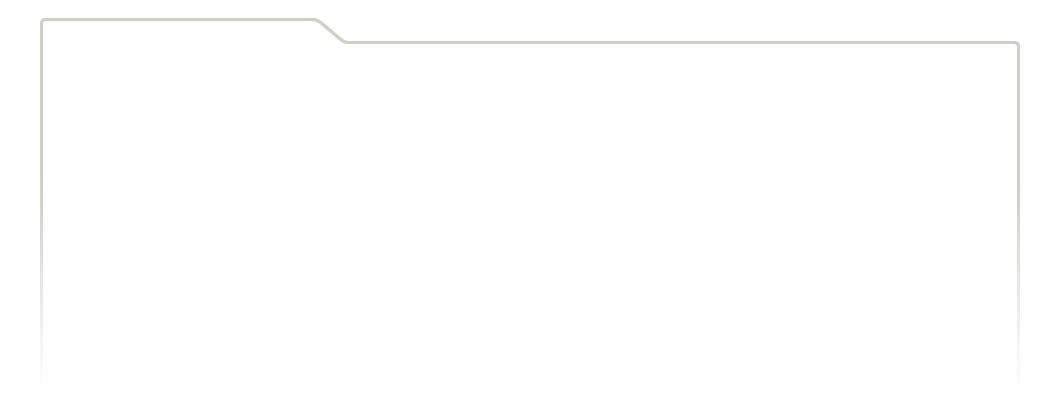
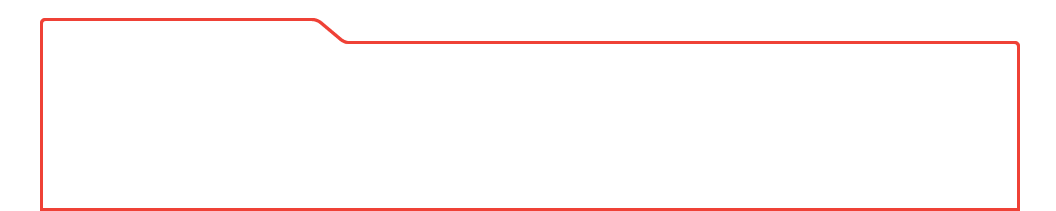
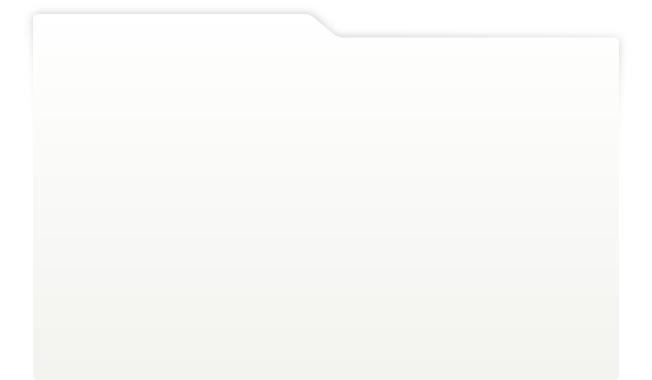
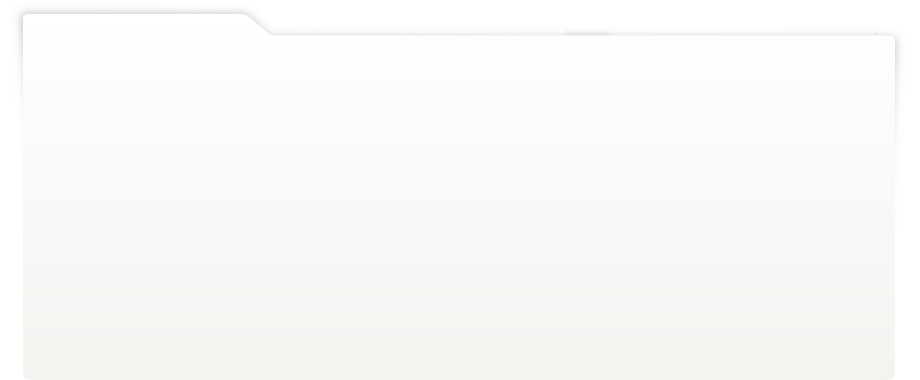
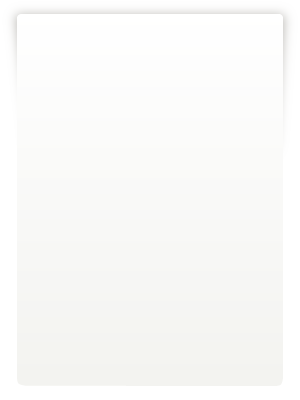
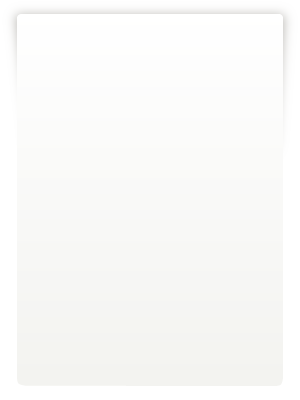
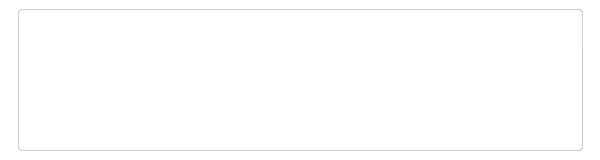
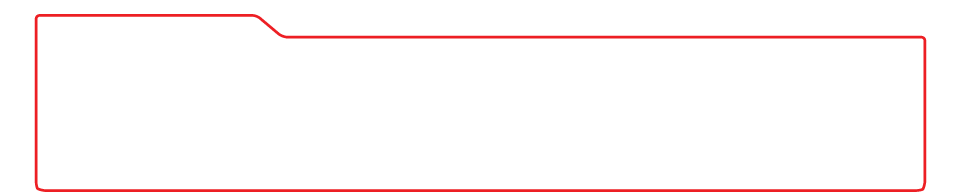
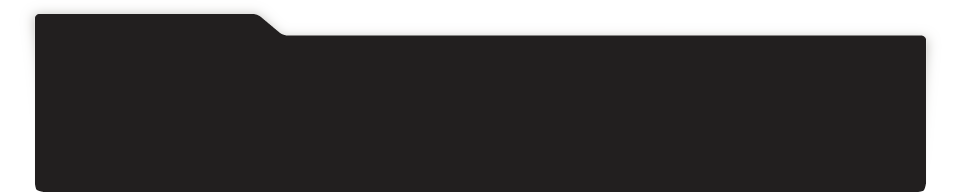
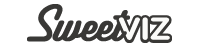
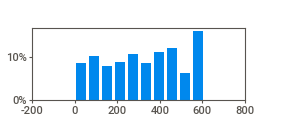
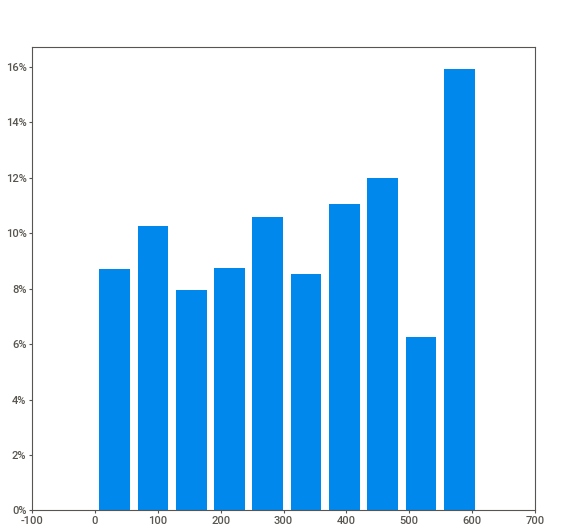
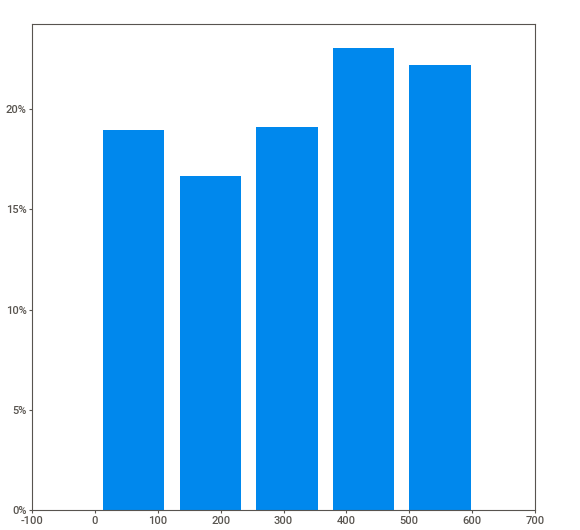
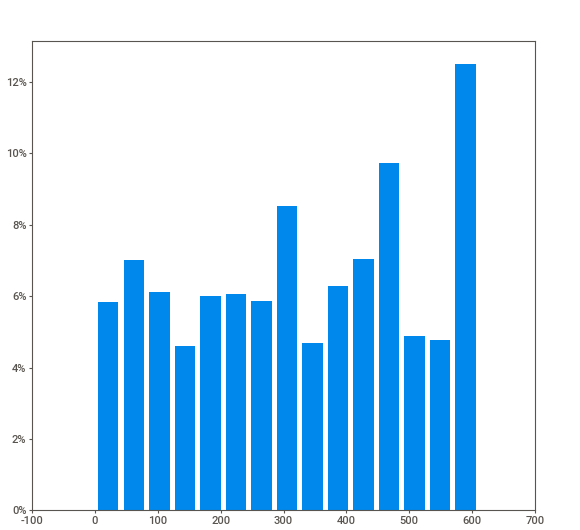
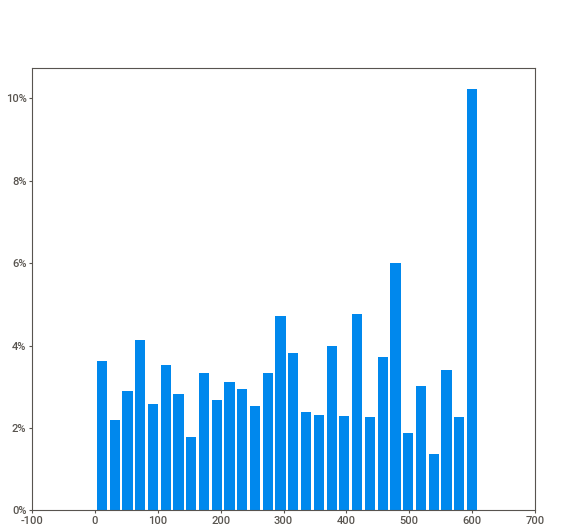
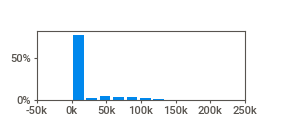
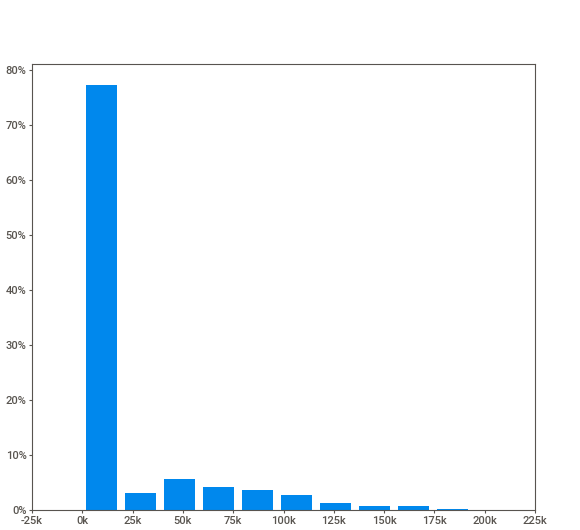
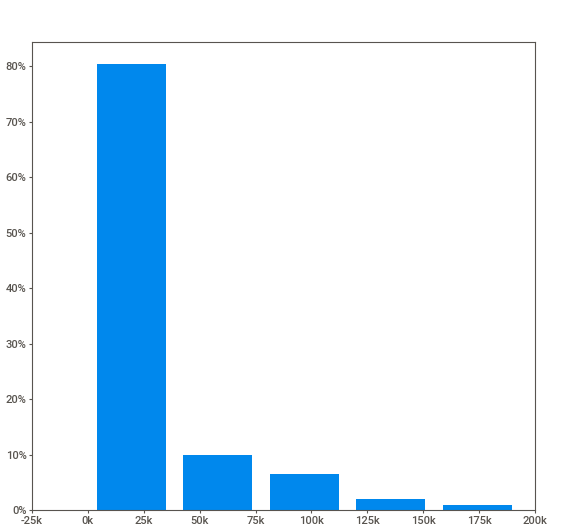
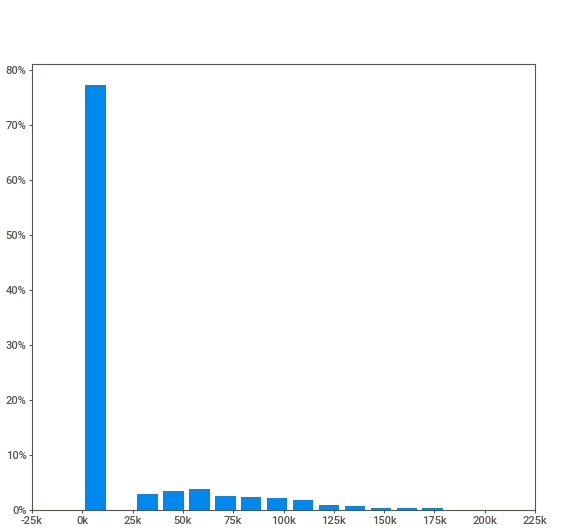
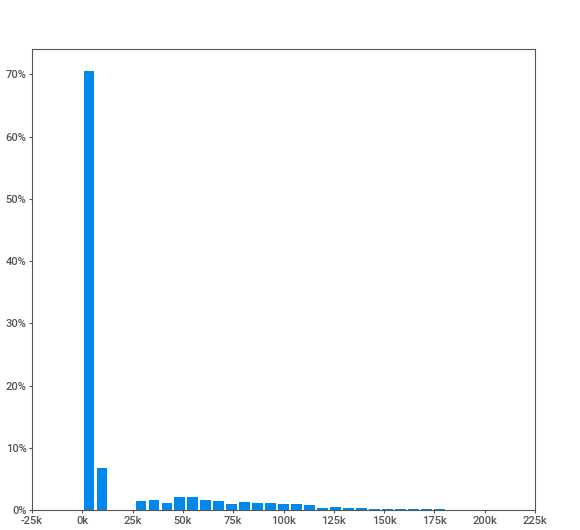
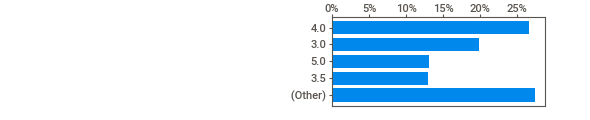
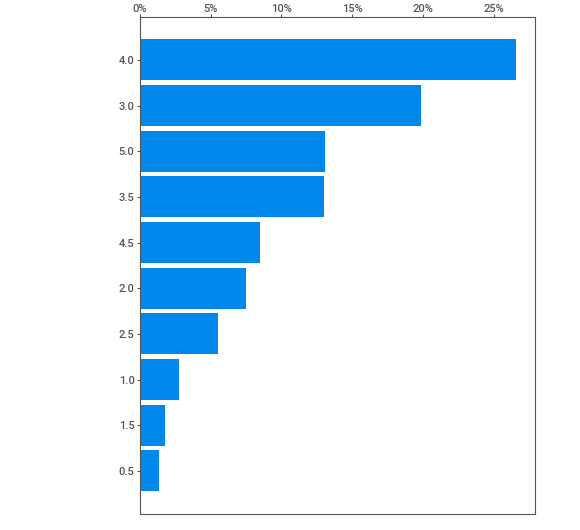
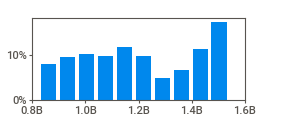
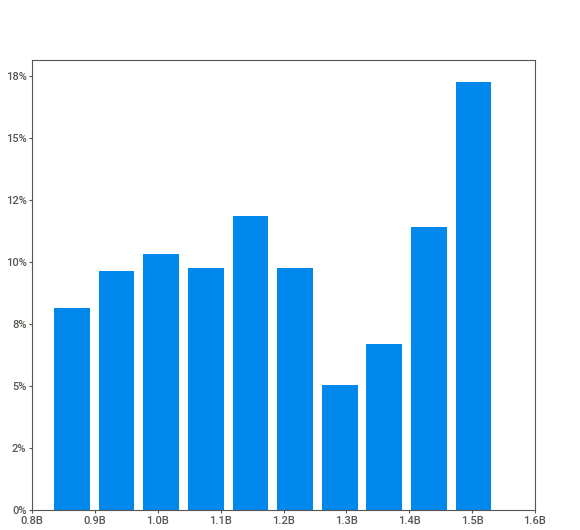
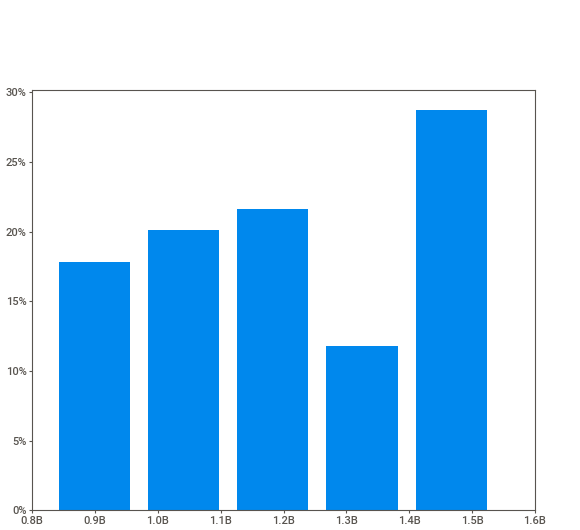
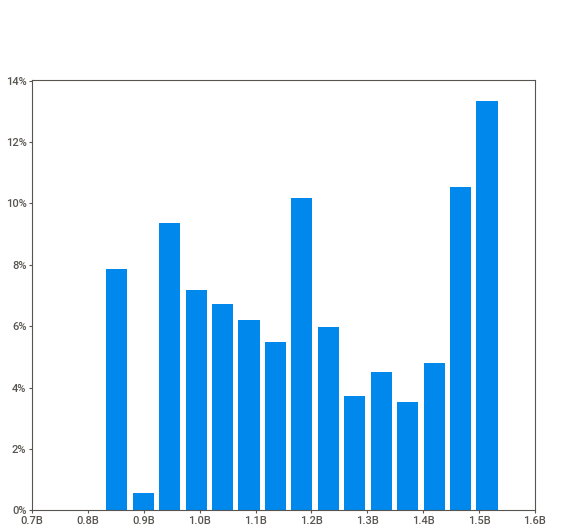
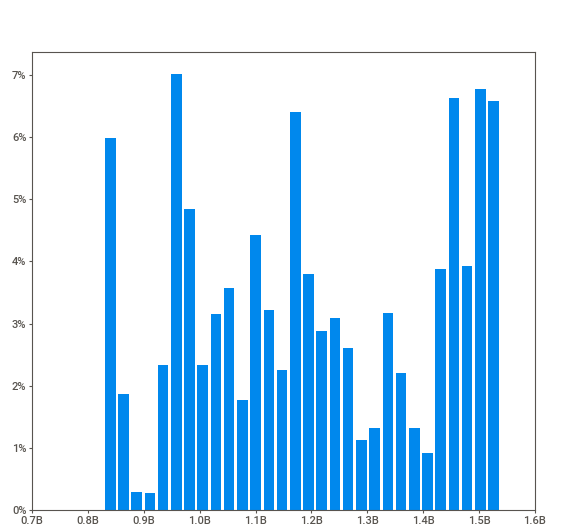
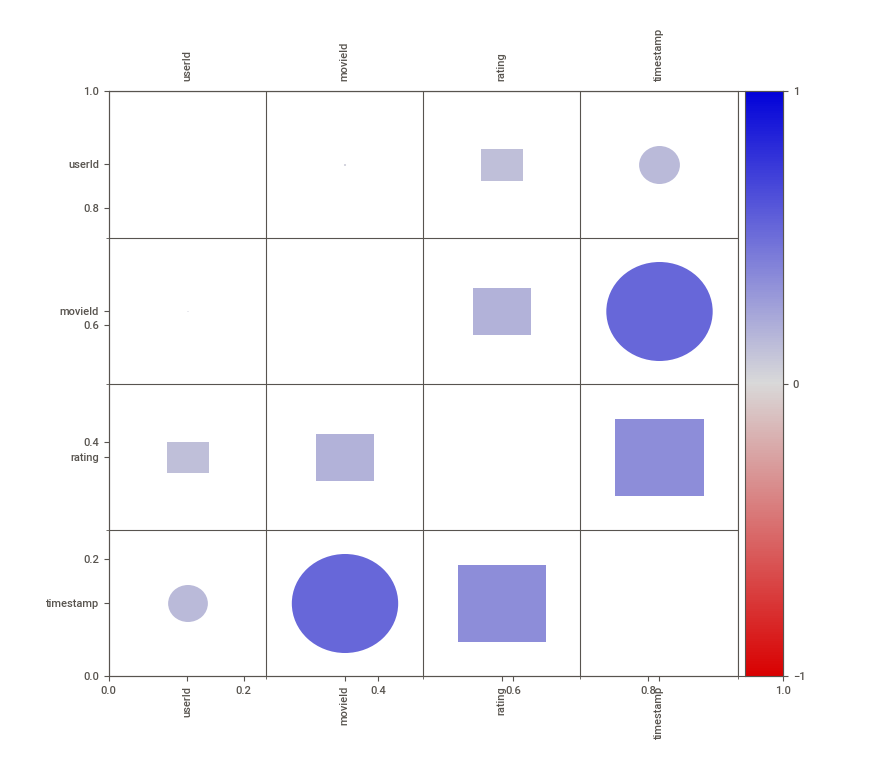
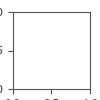

✅ ratings analysé - 100836 lignes, 4 colonnes

⏳ Génération du rapport pour: tags...


                                             |          | [  0%]   00:00 -> (? left)


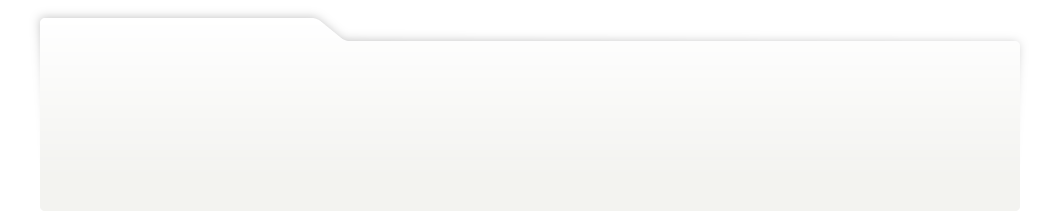
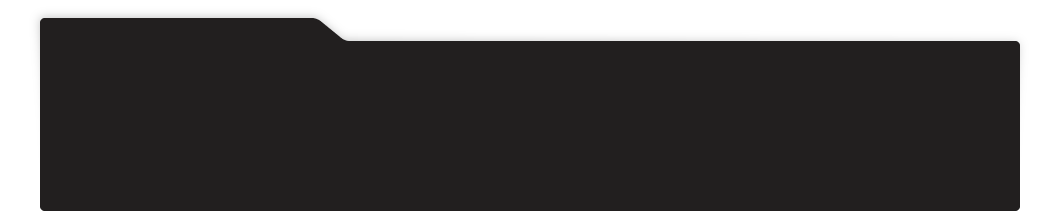
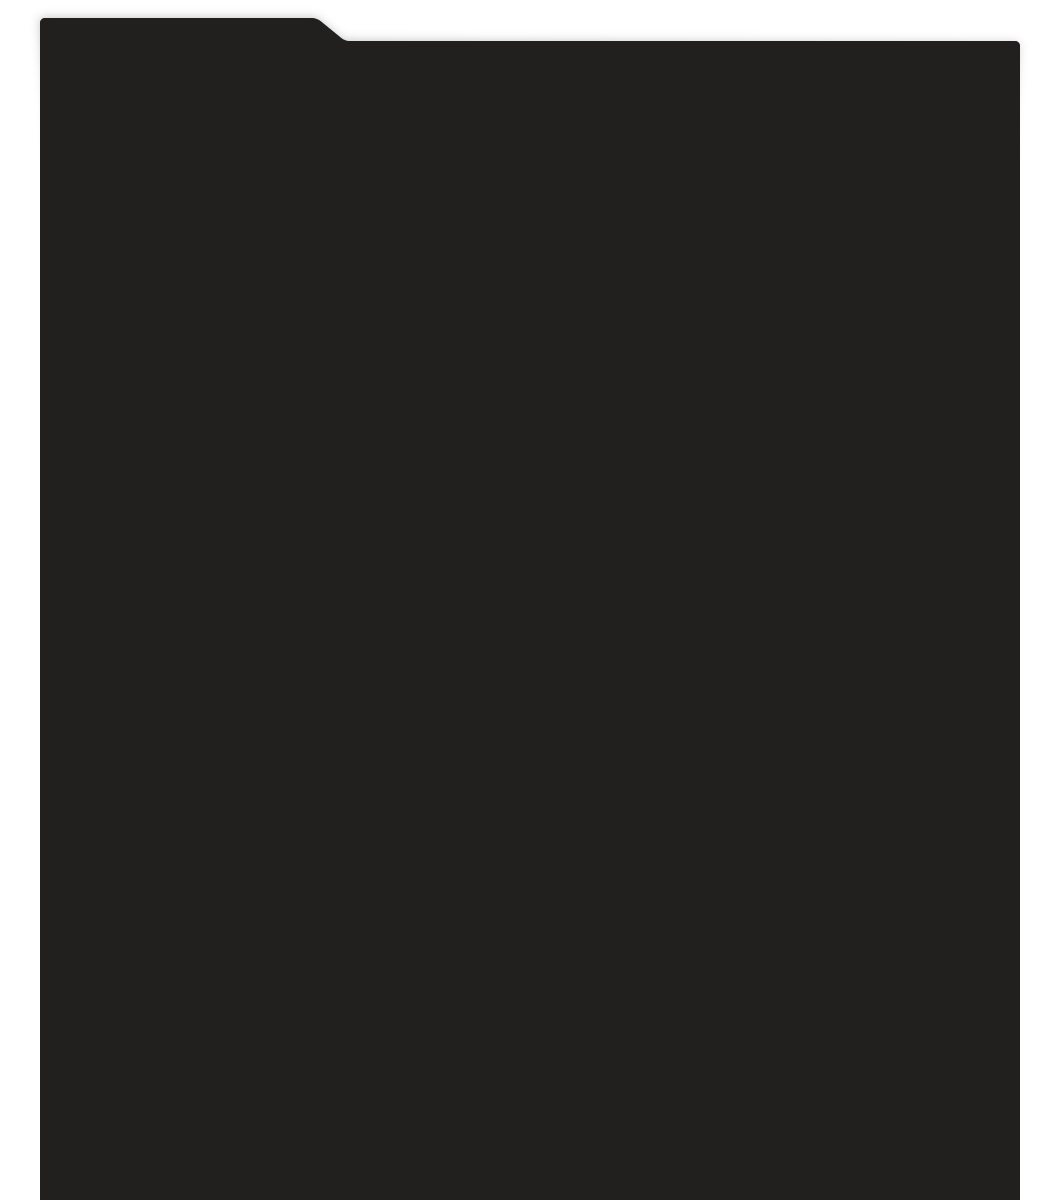
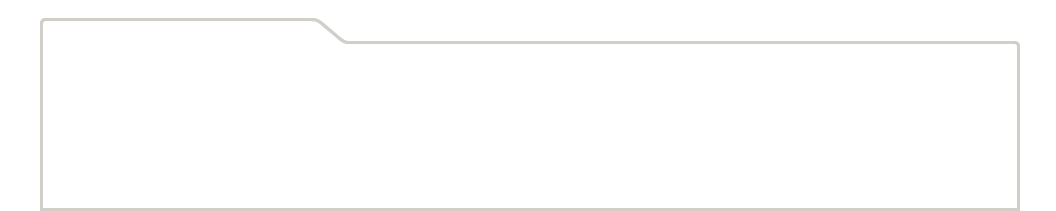
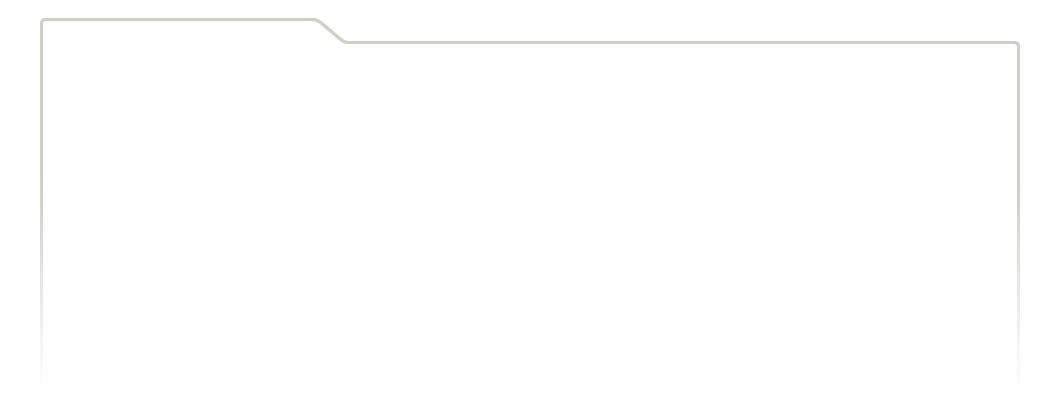
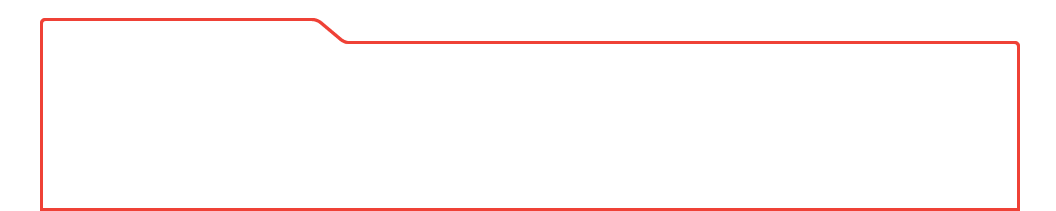
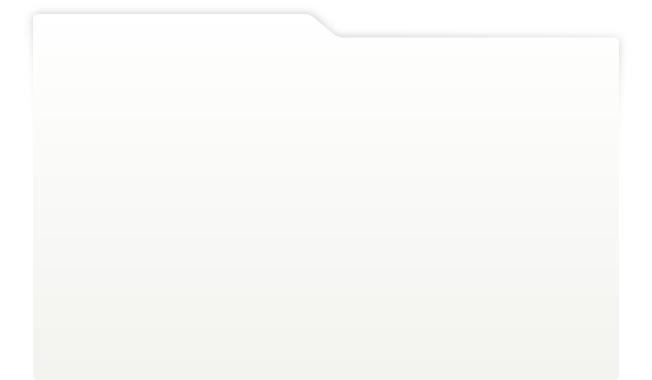
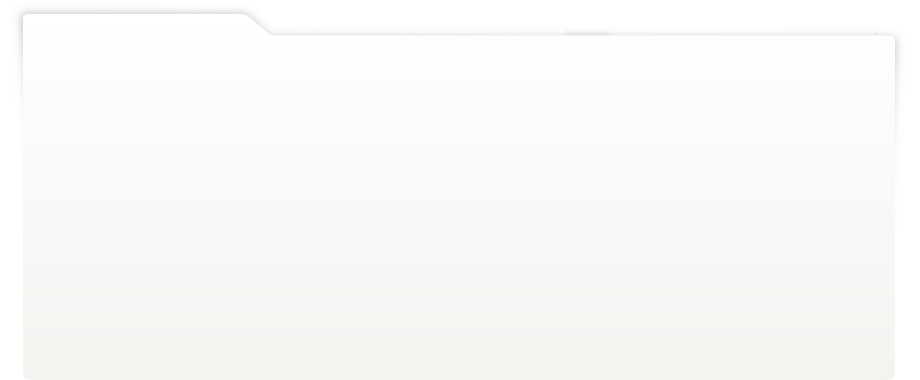
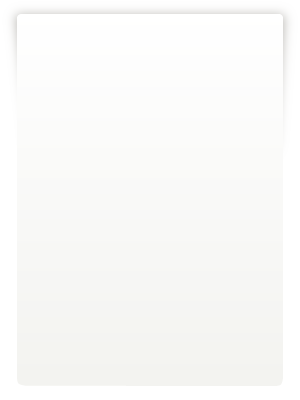
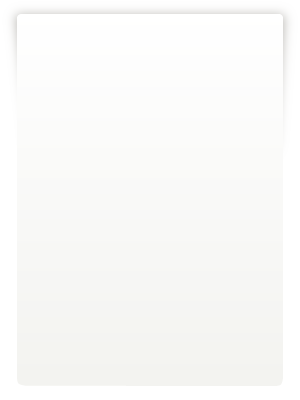
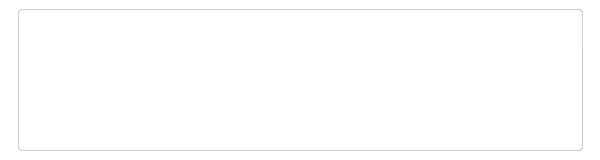
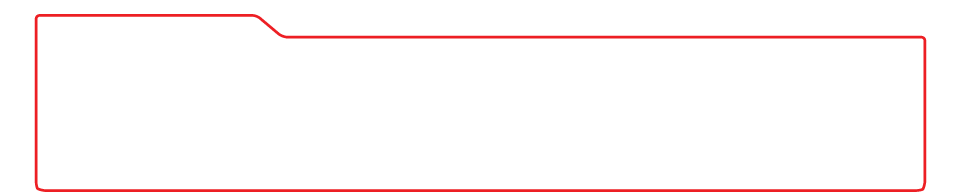
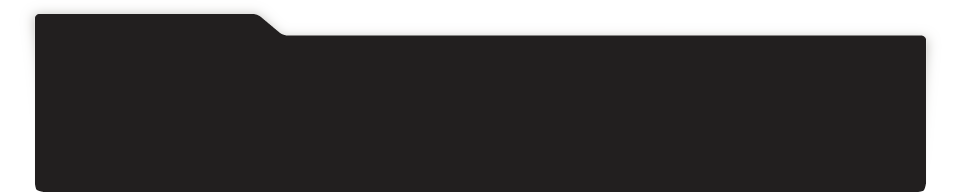
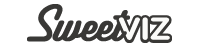
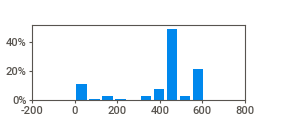
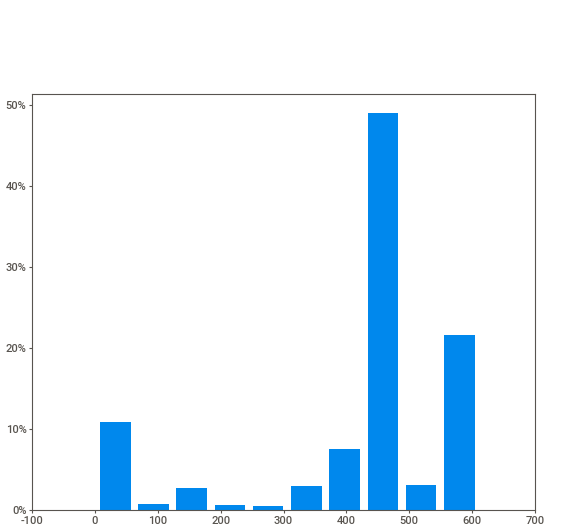
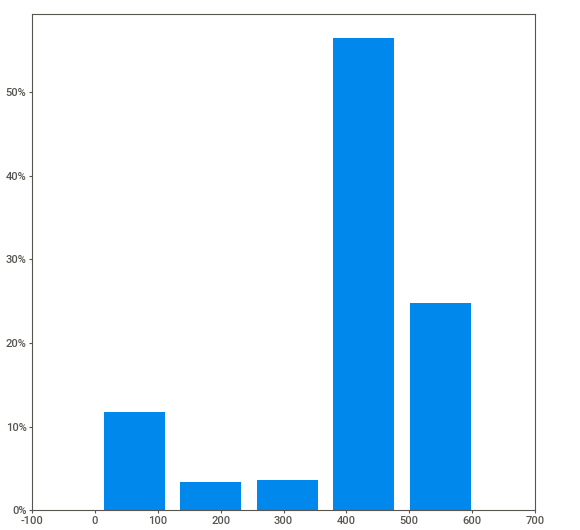
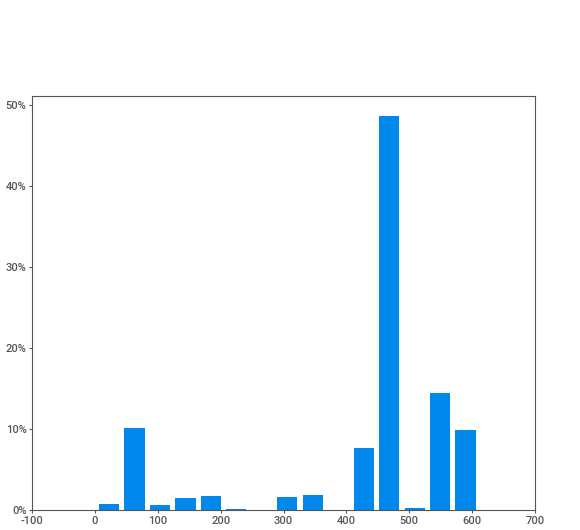
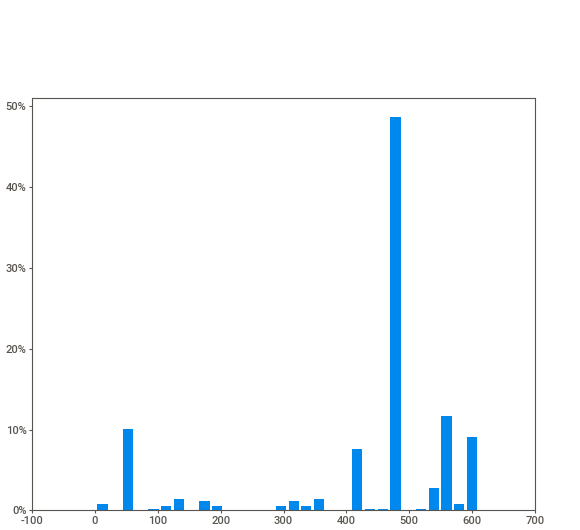
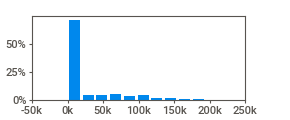
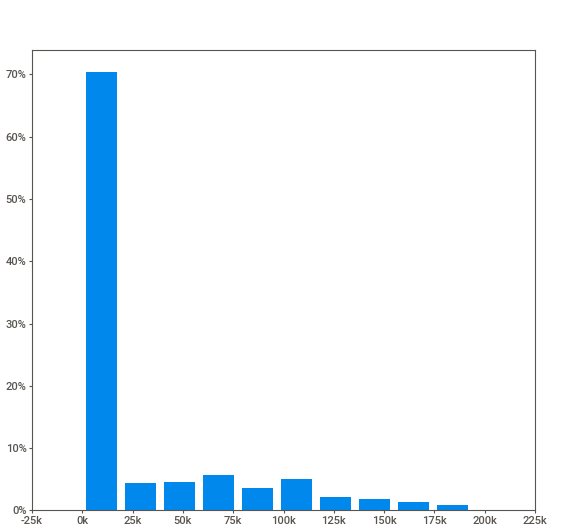
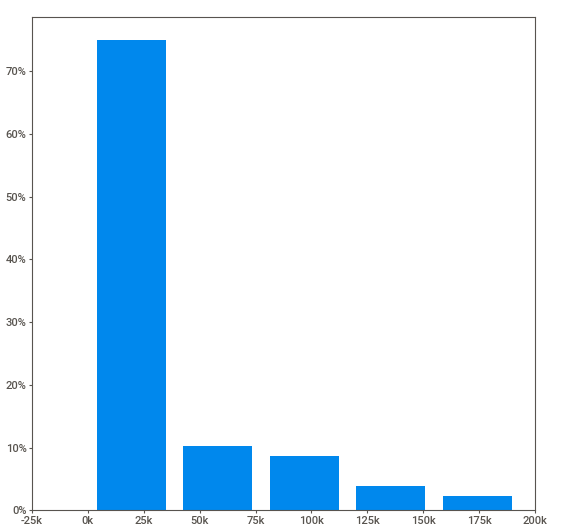
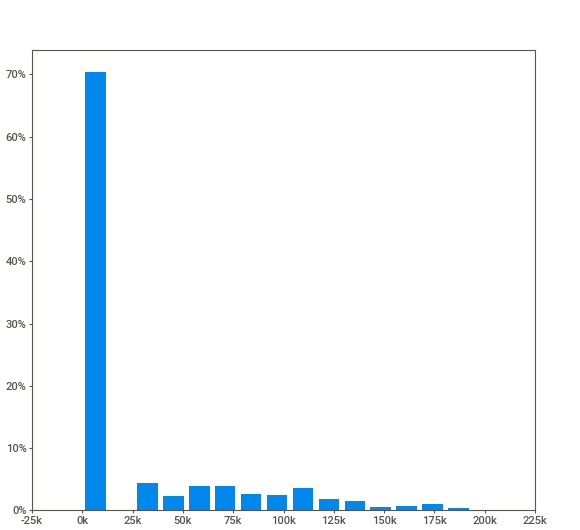
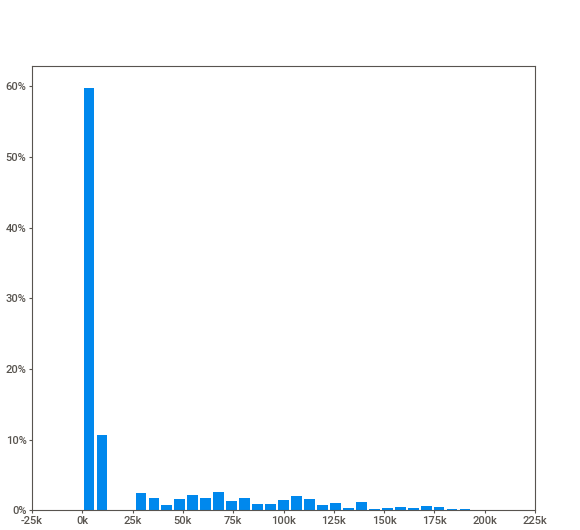
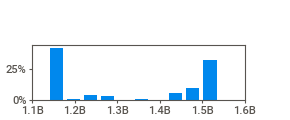
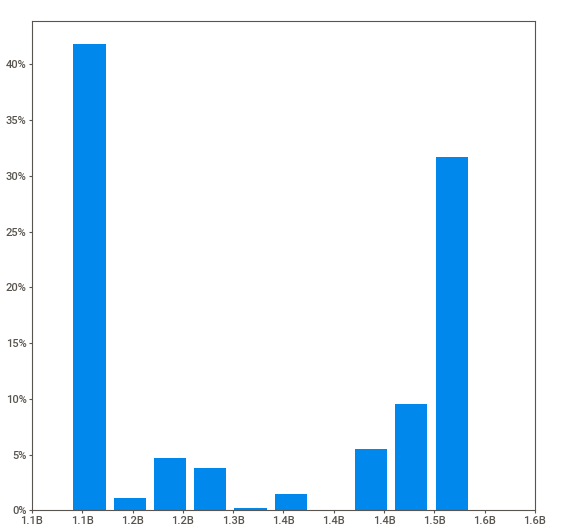
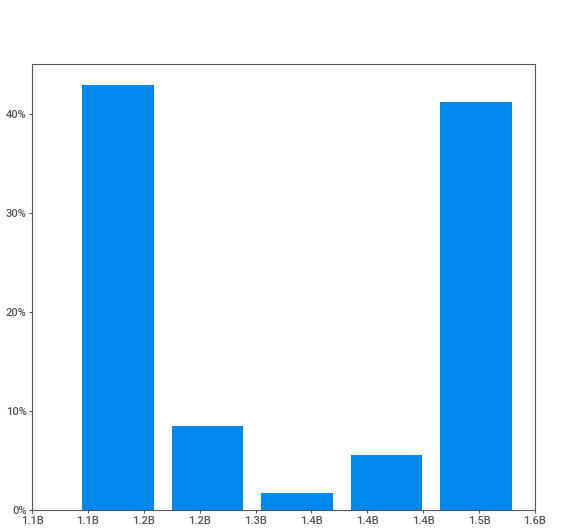
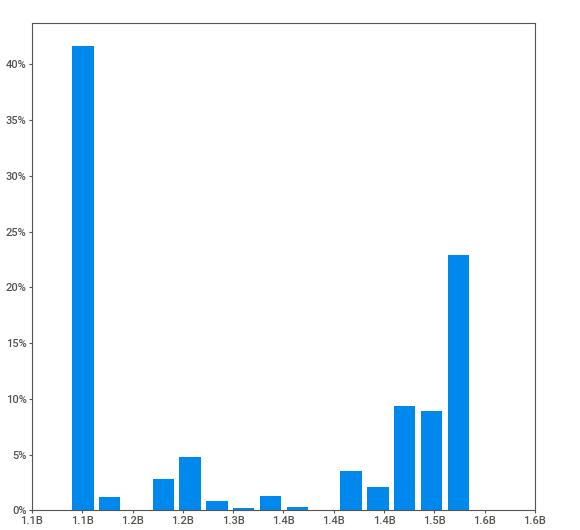
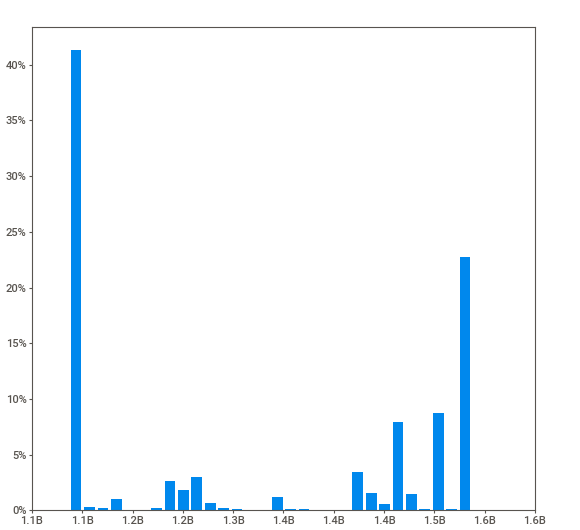
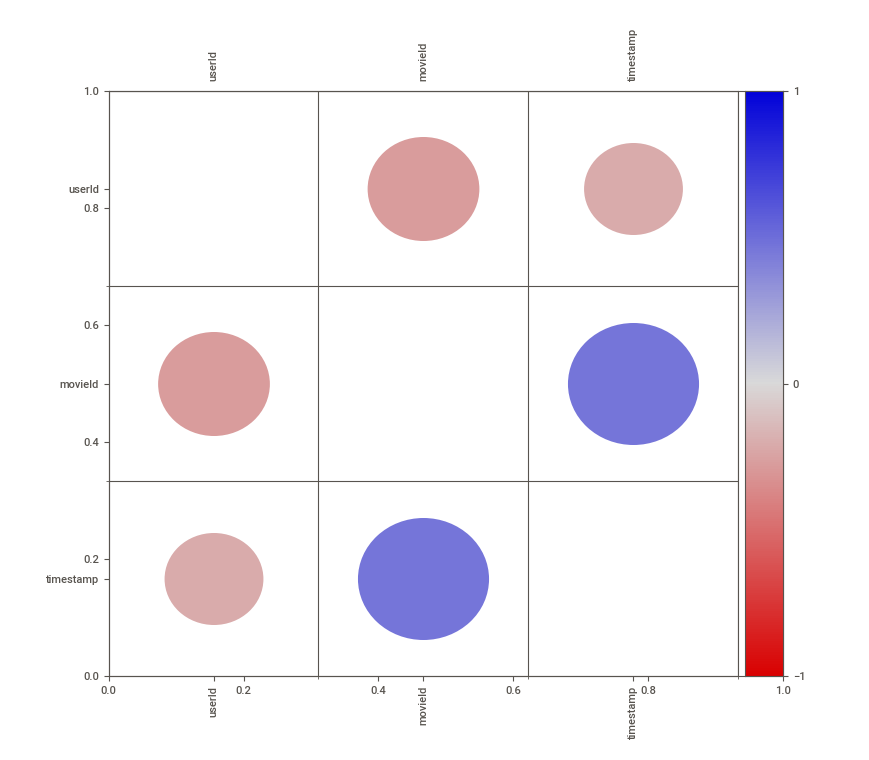
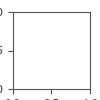

✅ tags analysé - 3683 lignes, 4 colonnes



In [30]:
import sweetviz as sv

def generer_rapport_sweetviz(df, nom_table, colonne_cible=None):

    print(f"⏳ Génération du rapport pour: {nom_table}...")

    rapport = sv.analyze(
        df,
        target_feat=colonne_cible
    )

    rapport.show_notebook()
    print(f"✅ {nom_table} analysé - {df.shape[0]} lignes, {df.shape[1]} colonnes\n")

# Exécution
tables = {
    'movies': (df1, None),
    'links': (df2, None),
    'ratings': (df3, None),  # Tu peux mettre 'rating' si tu veux une analyse comparative
    'tags': (df4, None)
}

for nom_table, (df, colonne_cible) in tables.items():
    generer_rapport_sweetviz(df, nom_table, colonne_cible)

- Table movies: aucun doublons
- Table links doublons dans la colonne tmdbld